### 2차 실험(프로젝트) 요약 및 회고
#### 실험 요약
- 본 프로젝트는 GRU를 활용한 Seq2Seq를 개발하여 한국어를 영어로 번역하는 번역기 개발을 목적으로 함
- 토큰화는 SentencePiece(BPE)로 vocab의 규모를 줄임
- Seq2Seq 모델은 3종(바닐라모델 및 2개의 Attention 모델)를 설계 및 학습하고 평가하였음.
- 이번에는 train 데이터셋 9:1로 train dataset vs validation으로 나누고, dev 데이터셋을 Validation에 활용하지 않았음.
- 학습 초기에 validation loss가 불안정하여 조기종료되는 것을 막기 위해 Two Track으로 학습, TracK A에는 WARMUP_EPOCHS 도입.
- WARMUP_EPOCHS 동안: Val은 TF=1.0로만 측정하되, best/earlystop/scheduler 카운트 금지
- 이후(=epoch WARMUP+1부터): Val은 TF=0.0로 측정, 그때부터 best/earlystop/scheduler 시작
- Track-B free-run subset은 그대로(정성 모니터링)
#### 2차 실험 회고
- 이번 실험은 지독한 삽질의 시간이었음. 
- 성과는 좋지 않지는 않았지만 중고차를 수리하는 수리공의 마음으로 기능을 하나하나 분석하고
- 실험조건이 변경함에 비록 낮은 성능이지만 결과가 달라지는 것을 확인하면서 AI Engineer로 재미있는 일(job)일 수 있다는 희망을 가져봄
- 실험 결과는 앞에서와 같이 Bahdanau가 가장 안정적, Luong, Vanilla 순으로 성능을 보임
  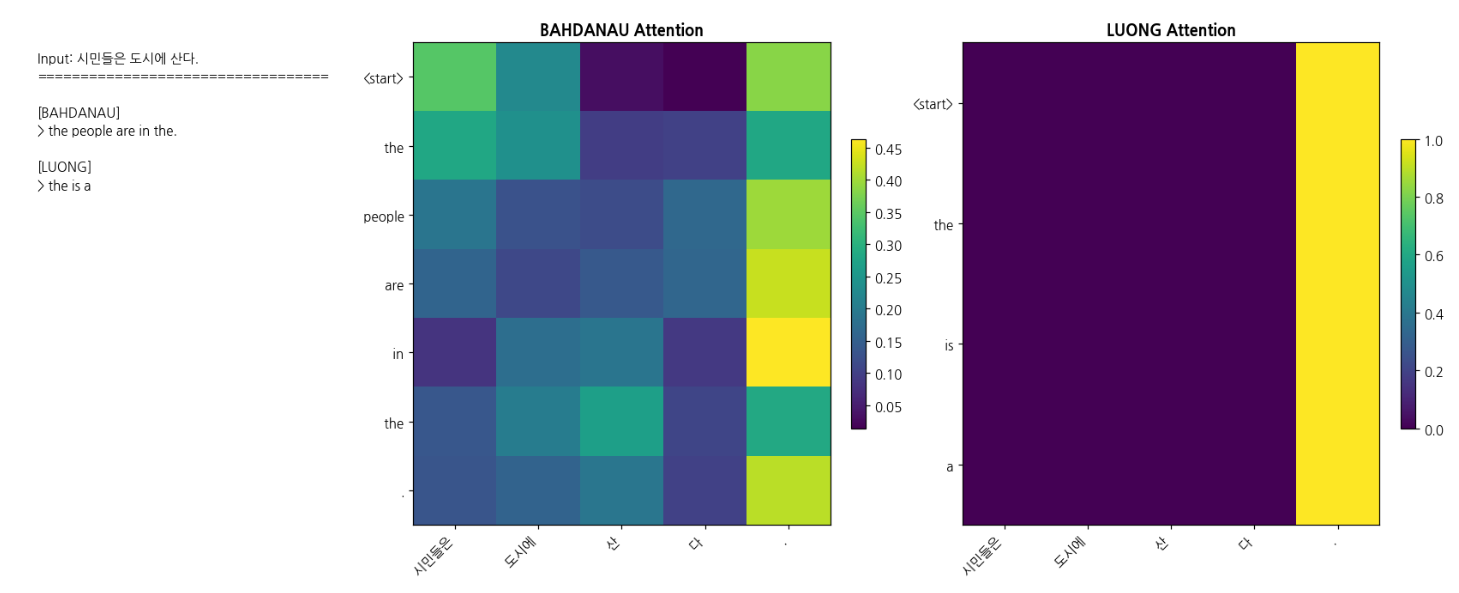

### Task 확인 및 프로젝트 방향
---
#### Task 확인 : Seq2Seq으로 한-영 번역기 만들기(입력: 한국어, 출력: 영어)
---
### Project Process(수정)
---
#### Step 1 데이터 다운로드
- 필요 라이브러리 import 및 버전 확인
- 데이터 다운로드 및 구조 확인(train/test만 사용)
- Train: 학습용 원본
- Test: 최종 평가에만 사용(단 한 번)
#### Step 2 데이터 정제
- Task 목적/데이터 특징에 맞게 정제 요소 확정
- (kor, eng) 병렬쌍 유지하며 중복 제거
- 한/영 각각 정규화(특수문자, 공백, 기호 처리 등)
- 정제 전/후 길이 분포 및 품질 점검
- 길이 40 이하 필터링하여 학습 코퍼스 구성
- 문제 대응 전략(부정문/마침표 편향/품질)
- 부정문 패턴 보존 체크: 없다/않다/못하다/아니다/필요 없다가 정제 과정에서 깨지지 않도록 규칙 점검
#### Step 3 데이터 토큰화
- SentencePiece(BPE) 토큰화
- 토큰 길이/어휘 크기 분포 확인, vocab size ≥ 10,000
→ BLEU/chrF 계산 직전에 반드시 detokenize 적용(아포스트로피/공백/구두점 복원)
#### Step 4 데이터 파이프인 및 모델설계
- data pipeline 설계
- Vanilla Seq2Seq
- Bahdanau Attention Seq2Seq
- Luong Attention Seq2Seq시작
#### Step 5 모델 
- Two Track으로 학습
- TracK A에는 WARMUP_EPOCHS 도입지)
Track-B free-run subset은 그대로(정성 모니터링) 

#### Step 6 모델 평가
- Attention Map 
- Test 전체에 대해 Corpus BLEU
- 보조 지표로 chrF, BLEU+chrF
- 3개 모델 성능 비교 및 에러 분석(짧은 문장/고유명사/부정문 첨부

## Step 1 데이터 다운로드
- 필요 라이브러리 import 및 버전 확인
- 데이터 다운로드 및 구조 확인(train/test만 사용)
- Train: 학습용 원본
- Test: 최종 평가에만 사용(단 한 번)

In [1]:
# ============================================================
# [STEP 0-CELL 0] GPU 캐시 초기화 및 환경 설정
# ============================================================
import torch
import gc
import os

# 1. GPU 캐시 및 메모리 비우기
def clear_gpu_cache():
    # Python 가비지 컬렉션 강제 실행
    gc.collect()
    # PyTorch의 CUDA 캐시 비우기
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print(f"[OK] GPU 캐시가 비워졌습니다. (현재 사용 중: {torch.cuda.memory_allocated() / 1024**2:.2f} MB)")
    else:
        print("[Info] CUDA를 사용할 수 없는 환경입니다.")

clear_gpu_cache()

# 2. 결과 저장 경로 초기화 (필요 시)
SAVE_DIR = "s2s_translation/checkpoints"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

[OK] GPU 캐시가 비워졌습니다. (현재 사용 중: 0.00 MB)


In [3]:
# ============================================================
# [STEP 1-CELL 1] 환경 설정 및 재현성 고정
# ============================================================

import os
import re
import urllib.request
import tarfile
import random
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Device & Version
print(f"torch: {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
seed_everything(42)

# 3. Matplotlib Font (Windows NanumGothic)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
font_path = r"C:\Windows\Fonts\NanumGothic.ttf"
if os.path.exists(font_path):
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False
    print(f"Font set: {font_name}")
else:
    print("Warning: NanumGothic font not found.")

torch: 2.8.0+cu126 | device: cuda
Font set: NanumGothic


In [5]:
# ============================================================
# [STEP 1-CELL 2] 경로 정의 및 데이터 다운로드/압축해제
# ============================================================

# 1. Path Configuration
project_root = Path("s2s_translation").resolve()
dataset_root = project_root / "datasets" / "ko_en_news_v1"
dl_dir, raw_dir = dataset_root / "downloads", dataset_root / "raw"
for p in [dl_dir, raw_dir]: p.mkdir(parents=True, exist_ok=True)

# 2. Download & Extract Utils
def download_and_extract(url, split):
    tar_path = dl_dir / f"korean-english-park.{split}.tar.gz"
    extract_path = raw_dir / f"{split}_raw"
    
    # Download
    if not tar_path.exists():
        print(f"[DOWN] {split} dataset...")
        urllib.request.urlretrieve(url, str(tar_path))
    
    # Extract
    if not any(extract_path.iterdir() if extract_path.exists() else []):
        extract_path.mkdir(parents=True, exist_ok=True)
        print(f"[EXTR] {split} dataset...")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=extract_path)
    return extract_path

urls = {
    "train": "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz",
    "test":  "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.test.tar.gz",
}

# 변수 할당 수정 완료
split_raw_dirs = {split: download_and_extract(url, split) for split, url in urls.items()}
print(f"[OK] Project Root: {project_root}")

[OK] Project Root: D:\PyProject\AIFFEL_AI\LLM\s2s_translation


In [7]:
# ============================================================
# [STEP 1-CELL 3] 데이터 로드 (Parallel DataFrame)
# ============================================================
def load_parallel_df(split_dir, split_name):
    files = list(split_dir.rglob(f"*{split_name}*"))
    ko_path = sorted([p for p in files if p.suffix == ".ko"])[0]
    en_path = sorted([p for p in files if p.suffix == ".en"])[0]

    with open(ko_path, "r", encoding="utf-8") as f: kor = [l.strip() for l in f]
    with open(en_path, "r", encoding="utf-8") as f: eng = [l.strip() for l in f]

    df = pd.DataFrame({"kor": kor, "eng": eng})
    print(f"[{split_name.upper()}] Loaded: {len(df):,} pairs")
    return df

train_df = load_parallel_df(split_raw_dirs["train"], "train")
test_df  = load_parallel_df(split_raw_dirs["test"],  "test")

[TRAIN] Loaded: 94,123 pairs
[TEST] Loaded: 2,000 pairs


In [9]:
# ============================================================
# [STEP 1-CELL 4] 정교한 데이터 통계 및 리포트 (통합 버전)
# ============================================================
def summarize_split(df, name="train"):
    # 1. 기본 메트릭 계산
    n = len(df)
    kor_char = df["kor"].astype(str).str.len()
    eng_char = df["eng"].astype(str).str.len()
    kor_tok  = df["kor"].astype(str).str.split().str.len()
    eng_tok  = df["eng"].astype(str).str.split().str.len()

    dup = df.duplicated(subset=["kor","eng"]).sum()
    
    # 한글 비율 계산 (분모 0 방지)
    total_kor_len = kor_char.sum()
    kor_hangul_ratio = df["kor"].astype(str).str.count(r"[가-힣]").sum() / max(1, total_kor_len)
    
    total_eng_len = eng_char.sum()
    eng_hangul_ratio = df["eng"].astype(str).str.count(r"[가-힣]").sum() / max(1, total_eng_len)

    summary = {
        "name": name,
        "n": n,
        "dup_pairs": int(dup),
        "dup_ratio": float(dup / max(1, n)),
        # Character Stats
        "kor_char_min": float(kor_char.min()), "kor_char_med": float(kor_char.median()), 
        "kor_char_mean": float(kor_char.mean()), "kor_char_max": float(kor_char.max()),
        "eng_char_min": float(eng_char.min()), "eng_char_med": float(eng_char.median()), 
        "eng_char_mean": float(eng_char.mean()), "eng_char_max": float(eng_char.max()),
        # Token Stats (whitespace based)
        "kor_tok_min": float(kor_tok.min()), "kor_tok_med": float(kor_tok.median()), 
        "kor_tok_mean": float(kor_tok.mean()), "kor_tok_max": float(kor_tok.max()),
        "eng_tok_min": float(eng_tok.min()), "eng_tok_med": float(eng_tok.median()), 
        "eng_tok_mean": float(eng_tok.mean()), "eng_tok_max": float(eng_tok.max()),
        # Language Ratio
        "kor_hangul_ratio": float(kor_hangul_ratio),
        "eng_hangul_ratio": float(eng_hangul_ratio),
        # 원본 시리즈 보존 (시각화용)
        "kor_tok_series": kor_tok,
        "eng_tok_series": eng_tok,
        "kor_char_series": kor_char,
        "eng_char_series": eng_char,
    }

    # 2. 콘솔 출력
    print(f"\n" + "="*20 + f" {name.upper()} SUMMARY " + "="*20)
    print(f"Total sentence pairs: {n:,}")
    print(f"Duplicate pairs     : {dup:,} ({summary['dup_ratio']*100:.2f}%)")
    print(f"Hangul ratio        | Kor: {kor_hangul_ratio:.4f} | Eng: {eng_hangul_ratio:.4f}")
    print(f"Kor token len (ws)  : min={summary['kor_tok_min']:.0f}, med={summary['kor_tok_med']:.0f}, mean={summary['kor_tok_mean']:.1f}, max={summary['kor_tok_max']:.0f}")
    print(f"Eng token len (ws)  : min={summary['eng_tok_min']:.0f}, med={summary['eng_tok_med']:.0f}, mean={summary['eng_tok_mean']:.1f}, max={summary['eng_tok_max']:.0f}")
    print(f"Kor char len        : min={summary['kor_char_min']:.0f}, med={summary['kor_char_med']:.0f}, mean={summary['kor_char_mean']:.1f}, max={summary['kor_char_max']:.0f}")
    print(f"Eng char len        : min={summary['eng_char_min']:.0f}, med={summary['eng_char_med']:.0f}, mean={summary['eng_char_mean']:.1f}, max={summary['eng_char_max']:.0f}")

    return summary

# 통계 실행 및 저장
pre_stats = {
    "train": summarize_split(train_df, "train"),
    "test":  summarize_split(test_df,  "test"),
}


==================== TRAIN SUMMARY ====================
Total sentence pairs: 94,123
Duplicate pairs     : 15,182 (16.13%)
Hangul ratio        | Kor: 0.6846 | Eng: 0.0000
Kor token len (ws)  : min=1, med=14, mean=14.0, max=82
Eng token len (ws)  : min=1, med=20, mean=20.9, max=90
Kor char len        : min=1, med=59, mean=60.8, max=377
Eng char len        : min=1, med=121, mean=126.1, max=605

==================== TEST SUMMARY ====================
Total sentence pairs: 2,000
Duplicate pairs     : 4 (0.20%)
Hangul ratio        | Kor: 0.6904 | Eng: 0.0000
Kor token len (ws)  : min=1, med=15, mean=15.4, max=55
Eng token len (ws)  : min=1, med=22, mean=22.8, max=69
Kor char len        : min=2, med=65, mean=66.9, max=219
Eng char len        : min=10, med=132, mean=137.9, max=410


[ko_len] 95% of sentences are under length: 26.0
[en_len] 95% of sentences are under length: 39.0


C:\Users\hugctx\AppData\Local\Temp\ipykernel_41840\1342744732.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([train_df['ko_len'], train_df['en_len']], labels=['KOR', 'ENG'], patch_artist=True)


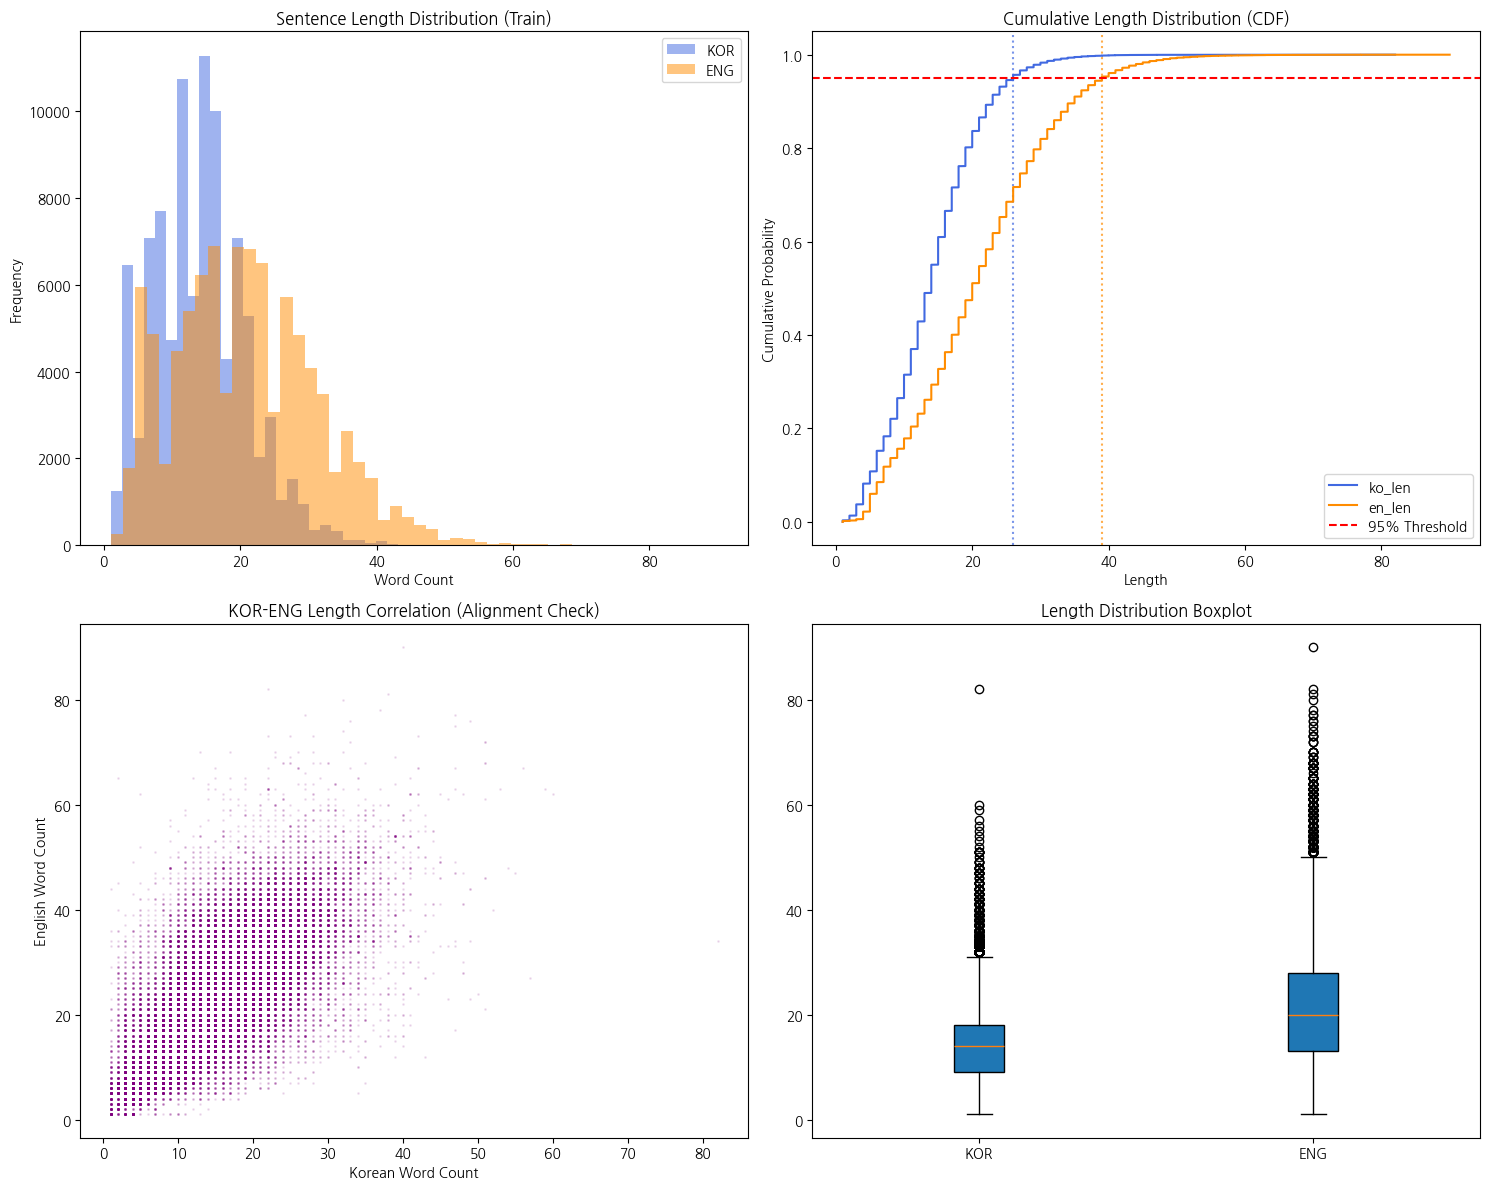

In [10]:
# ============================================================
# [STEP 1-CELL 5] 시각화 (업그레이드 버전)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# 0. 데이터프레임에 길이 정보가 없을 경우를 대비해 자동 생성
if 'ko_len' not in train_df.columns:
    train_df['ko_len'] = train_df['kor'].astype(str).apply(lambda x: len(x.split()))
if 'en_len' not in train_df.columns:
    train_df['en_len'] = train_df['eng'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 히스토그램 (어절 기준 분포)
axes[0, 0].hist(train_df['ko_len'], bins=50, alpha=0.5, label='KOR', color='royalblue')
axes[0, 0].hist(train_df['en_len'], bins=50, alpha=0.5, label='ENG', color='darkorange')
axes[0, 0].set_title("Sentence Length Distribution (Train)")
axes[0, 0].set_xlabel("Word Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# 2. 누적분포도 (CDF) - 95% 지점 파악용 (학습 Max_Len 결정 근거)
for col, c in zip(['ko_len', 'en_len'], ['royalblue', 'darkorange']):
    sorted_data = np.sort(train_df[col])
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data))
    axes[0, 1].plot(sorted_data, yvals, label=col, color=c)
    
    # P95 값 찾기 및 표시
    p95_val = np.percentile(sorted_data, 95)
    axes[0, 1].axvline(x=p95_val, color=c, linestyle=':', alpha=0.7)
    print(f"[{col}] 95% of sentences are under length: {p95_val:.1f}")

axes[0, 1].axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
axes[0, 1].set_title("Cumulative Length Distribution (CDF)")
axes[0, 1].set_xlabel("Length")
axes[0, 1].set_ylabel("Cumulative Probability")
axes[0, 1].legend()

# 3. 한-영 문장 길이 상관관계 (Scatter) - 정렬(Alignment) 품질 확인
axes[1, 0].scatter(train_df['ko_len'], train_df['en_len'], alpha=0.1, s=1, color='purple')
axes[1, 0].set_xlabel("Korean Word Count")
axes[1, 0].set_ylabel("English Word Count")
axes[1, 0].set_title("KOR-ENG Length Correlation (Alignment Check)")

# 4. 박스플롯 (이상치 및 데이터 밀집도 확인)
axes[1, 1].boxplot([train_df['ko_len'], train_df['en_len']], labels=['KOR', 'ENG'], patch_artist=True)
axes[1, 1].set_title("Length Distribution Boxplot")

plt.tight_layout()
plt.show()

## Step 2. 데이터 정제 및 품질 최적화
#### 목표: 병렬 코퍼스의 노이즈를 제거하고, 번역 모델의 편향(Bias)을 방지하는 고품질 학습 데이터셋 구축
#### 1. 주요 정제 프로세스
 - 병렬성 유지 및 중복 제거: (Kor, Eng) 쌍의 관계를 보존하며 중복 데이터 제거
 - 다국어 텍스트 정규화: 특수문자, 공백, HTML 태그 및 뉴스 메타데이터(기자명 등) 정제
 - 길이 기반 필터링: 학습 효율을 위해 어절 기준 40 토큰 이하 문장 선별
#### 2. 모델 성능 향상을 위한 특화 전략
 - 부정문 패턴 보존 (Negation Check)
 - 과도한 구두점 규격화로 인한 Attention 과집중 현상을 방지하기 위해 문장 끝 기호( . ? ! ) 분포 점검
 - 품질 모니터링: 정제 전/후 길이 분포 비교 및 샘플링을 통한 정성적 품질 평가

In [13]:
# ============================================================
# [STEP 2-CELL 1] Step2 올인원 복구 + 노이즈 필터 "전량삭제 방지" 패치 (v2.1-fixed)
# - 목적:
#   (1) 커널 리셋 후 이 셀 하나로 Step2(정제/필터/로깅/노이즈) 전부 복구
#   (2) noisy_code_like 과발동(전량삭제) 방지: "키워드 단독 제거 금지" + "형태 증거 기반"
# - 포함:
#   - assert_parallel_df
#   - preprocess_base / normalize_punct
#   - preprocess_ko / preprocess_en
#   - is_noisy_text(v2.1-fixed): code block/라인/구두점/심볼/반복/깨짐 탐지
#   - clean_parallel_corpus_with_log_v2 / clean_df_with_log_v2
# ============================================================

# ============================================================
# [STEP 0-INIT] ✅ 커널 리셋 후 첫 실행 셀
# ============================================================
import re
import unicodedata
from html import unescape
from collections import Counter
from typing import List, Tuple, Dict, Any
import numpy as np
import pandas as pd

print("[OK] Step2 v2.1-fixed init loaded.")

# -----------------------------
# 0) 안전장치: 입력 DF 점검
# -----------------------------
def assert_parallel_df(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    assert isinstance(df, pd.DataFrame), f"{name} must be a DataFrame"
    assert "kor" in df.columns and "eng" in df.columns, f"{name} must have columns: ['kor','eng']"
    if df["kor"].isna().any() or df["eng"].isna().any():
        print(f"[WARN] {name}: NaN detected. Filling with empty string.")
        df["kor"] = df["kor"].fillna("")
        df["eng"] = df["eng"].fillna("")
    return df

# -----------------------------
# 1) 기본 텍스트 정규화 유틸
# -----------------------------
ZW_CHARS = r"[\u200b\u200c\u200d\u2060\ufeff]"  # zero-width/BOM

def preprocess_base(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = unescape(text)
    text = re.sub(r"<\s*br\s*/?\s*>", " ", text, flags=re.I)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", " ", text)  # email
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # url
    return text

def normalize_punct(text: str) -> str:
    # quotes/dash normalization
    text = re.sub(r"[“”„]", '"', text)
    text = re.sub(r"[‘’´`]", "'", text)
    text = re.sub(r"[—–−]", "-", text)
    text = text.replace("…", "...")
    # control chars + zero-width 제거
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", " ", text)
    text = re.sub(ZW_CHARS, "", text)
    # spaces
    return re.sub(r"\s+", " ", text).strip()

# -----------------------------
# 2) 뉴스 메타 제거 + 언어 교차 필터
# -----------------------------
META_KO = [
    r"[가-힣]{2,4}\s*기자",
    r"\([^)]*(뉴스|로이터|AP|AFP|통신|연합|JOINS)[^)]*\)",
]
META_EN = [
    r"^\s*by\s+[a-z]+\s+[a-z]+.*",
    r"\([^)]*(reuters|ap|afp|news)[^)]*\)",
]

def remove_meta(text: str, patterns: List[str], flags: int = 0) -> str:
    for pat in patterns:
        text = re.sub(pat, " ", text, flags=flags)
    return text

def is_bad_language_match(ko: str, en: str) -> bool:
    ko_alpha = len(re.findall(r"[A-Za-z]", ko))
    ko_hangul = len(re.findall(r"[가-힣]", ko))
    en_hangul = len(re.findall(r"[가-힣]", en))

    # 한국어가 거의 없고 영어만 많은 경우
    if ko_alpha >= 8 and ko_hangul <= 1:
        return True
    # 영어에 한글이 꽤 섞인 경우
    if en_hangul >= 3:
        return True
    return False

# -----------------------------
# 3) 언어별 전처리
# -----------------------------
def preprocess_ko(text: str) -> str:
    text = preprocess_base(text)
    text = remove_meta(text, META_KO)
    # 허용 문자 외 제거(너무 과격하면 의미 손실 → 필요 시 허용문자 확장)
    text = re.sub(r"[^가-힣A-Za-z0-9?.!,()\"'\-/% ]+", " ", text)
    return normalize_punct(text)

def preprocess_en(text: str) -> str:
    text = preprocess_base(text).lower()
    text = remove_meta(text, META_EN, flags=re.I)
    text = re.sub(r"[^a-z0-9?.!,()\"'\-/% ]+", " ", text)
    return normalize_punct(text)

# -----------------------------
# 4) 노이즈 탐지 규칙(v2.1-fixed) ✅ "형태 기반"
# -----------------------------
# (A) 코드블록/태그
CODE_BLOCK_RE = re.compile(r"```|<\s*code\s*>|<\s*/\s*code\s*>", re.I)

# (B) 코드/로그 '라인 형태' (✅ 반드시 정의 필요)
# - typical: "foo = bar", "def func(x):", "class X:", "Traceback ...", "File ... line ..."
CODE_LINE_RE = re.compile(
    r"(?im)("
    r"^\s*(def|class)\s+\w+.*:$|"
    r"^\s*import\s+\w+|^\s*from\s+\w+\s+import\s+|"
    r"^\s*\w+\s*=\s*.+$|"
    r"^\s*(Traceback|File\s+\".*\", line\s+\d+|Exception|Error:).*$"
    r")"
)

# (C) 코드 구두점 비율(많으면 코드 가능성)
CODE_PUNCT_RE = re.compile(r"[{}\[\]<>;=\\|`$^~]")

# (D) 반복/깨짐 텍스트
REPEAT_TOKEN_RE = re.compile(r"(?i)\b(\w{1,3})\b(?:\s+\1){5,}")
WEIRD_O1_RE = re.compile(r"(?i)\bo\d+\b|\b\d+o\b")

# (E) 기술 키워드(단독 제거 금지: "약한 증거"로만 점수에 반영)
TECH_KEYWORD_RE = re.compile(
    r"(?i)\b("
    r"javascript|typescript|node\.js|\bnpm\b|\byarn\b|webpack|babel|"
    r"pytorch|tensorflow|cuda|bash|terminal|cli|"
    r"traceback|stack\s*trace|syntaxerror|nameerror|typeerror|valueerror"
    r")\b"
)

def _symbol_ratio(s: str) -> float:
    # 문자 전체 대비 '특수기호' 비율(너무 높으면 깨진 텍스트 가능)
    sym = len(re.findall(r"[^0-9A-Za-z가-힣\s]", s))
    return sym / max(1, len(s))

def _code_punct_ratio(s: str) -> float:
    return len(CODE_PUNCT_RE.findall(s)) / max(1, len(s))

def is_noisy_text(ko: str, en: str, cfg: Dict[str, Any]) -> str:
    """
    정책:
      - noisy_code_like: 코드 '형태' 증거가 충분할 때만 제거
      - 기술 키워드는 단독 제거 금지(점수 +0.5 정도)
      - noisy_code_punct_heavy: 코드 구두점 비율이 높으면 즉시 제거(강한 증거)
      - noisy_symbol_heavy: 심볼 비율 과다 제거
      - noisy_repetition_or_garbled: 반복/깨짐 제거
    """
    # 완화된 기본값(전량삭제 방지)
    symbol_ratio_max = float(cfg.get("symbol_ratio_max", 0.35))
    code_punct_ratio_max = float(cfg.get("code_punct_ratio_max", 0.12))
    code_line_min_hits = int(cfg.get("code_line_min_hits", 1))
    code_like_min_score = float(cfg.get("code_like_min_score", 2.0))

    score = 0.0

    # 1) 코드블록 마커는 강한 증거
    if CODE_BLOCK_RE.search(en):
        score += 2.5

    # 2) 코드/로그 라인 히트
    line_hits = len(CODE_LINE_RE.findall(en))
    if line_hits >= code_line_min_hits:
        score += 2.0

    # 3) 코드 구두점 비율이 과다하면 즉시 제거(강한 증거)
    if _code_punct_ratio(en) > code_punct_ratio_max:
        return "noisy_code_punct_heavy"

    # 4) 기술 키워드는 약한 증거(단독 제거 X)
    if TECH_KEYWORD_RE.search(en):
        score += 0.5

    # 5) 점수 기준으로 코드형 제거
    if score >= code_like_min_score:
        return "noisy_code_like"

    # 6) 심볼 과다(깨짐/노이즈) 제거
    if _symbol_ratio(en) > symbol_ratio_max or _symbol_ratio(ko) > symbol_ratio_max:
        return "noisy_symbol_heavy"

    # 7) 반복/깨짐 패턴 제거
    if REPEAT_TOKEN_RE.search(en) or WEIRD_O1_RE.search(en):
        return "noisy_repetition_or_garbled"

    return ""

# -----------------------------
# 4B) 스모크 테스트(전량삭제/정규문 오탐 방지)
# -----------------------------
def _run_noise_smoke_tests():
    normal_1 = "cnn and cnn.com will carry the event live."
    normal_2 = "obama leads clinton, a fellow democratic senator."
    code_1 = "Traceback (most recent call last):\nNameError: name 'x' is not defined"
    code_2 = "def foo(x):\n    return x\nx = foo(3)"
    cfg = {"symbol_ratio_max": 0.35, "code_punct_ratio_max": 0.12, "code_like_min_score": 2.0, "code_line_min_hits": 1}

    n1 = is_noisy_text("정상 문장", normal_1, cfg)
    n2 = is_noisy_text("정상 문장", normal_2, cfg)
    c1 = is_noisy_text("정상 문장", code_1, cfg)
    c2 = is_noisy_text("정상 문장", code_2, cfg)

    print("[SMOKE] normal_1 reason:", n1)
    print("[SMOKE] normal_2 reason:", n2)
    print("[SMOKE] code_1   reason:", c1)
    print("[SMOKE] code_2   reason:", c2)

    # 정상은 웬만하면 통과(빈 문자열)
    if n1 or n2:
        print("[WARN] Smoke test: normal sentence got flagged. Consider loosening rules.")
    # 코드는 잡히는 게 자연스러움
    if (not c1) and (not c2):
        raise RuntimeError("[FATAL] Smoke test: code samples were NOT flagged. Noise filter is too weak.")

_run_noise_smoke_tests()
print("[OK] Noise rules ready (v2.1-fixed).")

# -----------------------------
# 5) 정제 메인(v2.1-fixed) + 제거 사유 로깅
# -----------------------------
def clean_parallel_corpus_with_log_v2(
    raw_pairs: List[Tuple[str, str]],
    cfg: Dict[str, Any],
) -> Tuple[List[Tuple[str, str]], Counter]:
    """
    cfg keys:
      - max_tokens (default 40) : 공백 토큰 기준 제한
      - ratio_min (default 0.3), ratio_max (default 3.5) : 문자 길이 비율 필터
      - min_chars (default 2) : 최소 문자 수
      - noise params:
          symbol_ratio_max (default 0.35)
          code_punct_ratio_max (default 0.12)
          code_line_min_hits (default 1)
          code_like_min_score (default 2.0)
    """
    seen = set()
    cleaned: List[Tuple[str, str]] = []
    reasons = Counter()

    max_tokens = int(cfg.get("max_tokens", 40))
    ratio_min = float(cfg.get("ratio_min", 0.3))
    ratio_max = float(cfg.get("ratio_max", 3.5))
    min_chars = int(cfg.get("min_chars", 2))

    for ko_raw, en_raw in raw_pairs:
        ko = preprocess_ko(ko_raw)
        en = preprocess_en(en_raw)

        if (not ko) or (not en):
            reasons["empty_after_preprocess"] += 1
            continue
        if len(ko) < min_chars or len(en) < min_chars:
            reasons["too_short_chars"] += 1
            continue
        if is_bad_language_match(ko, en):
            reasons["bad_language_match"] += 1
            continue

        noisy_reason = is_noisy_text(ko, en, cfg)
        if noisy_reason:
            reasons[noisy_reason] += 1
            continue

        ratio = len(ko) / max(1, len(en))
        if ratio < ratio_min or ratio > ratio_max:
            reasons["bad_length_ratio"] += 1
            continue

        if len(ko.split()) > max_tokens or len(en.split()) > max_tokens:
            reasons["over_max_tokens"] += 1
            continue

        if (ko, en) in seen:
            reasons["duplicate_pair"] += 1
            continue

        seen.add((ko, en))
        cleaned.append((ko, en))

    reasons["kept"] = len(cleaned)
    return cleaned, reasons

def clean_df_with_log_v2(df: pd.DataFrame, name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Counter]:
    df = assert_parallel_df(df.copy(), name=name)
    raw_pairs = list(zip(df["kor"].astype(str), df["eng"].astype(str)))
    cleaned_pairs, reasons = clean_parallel_corpus_with_log_v2(raw_pairs, cfg)
    out = pd.DataFrame(cleaned_pairs, columns=["kor", "eng"])
    print(f"\n[{name.upper()}] Raw: {len(df):,} -> Cleaned: {len(out):,} (Removed: {len(df)-len(out):,})")
    return out, reasons

print("[OK] Step2 v2.1-fixed functions restored (all-in-one).")

[OK] Step2 v2.1-fixed init loaded.
[SMOKE] normal_1 reason: 
[SMOKE] normal_2 reason: 
[SMOKE] code_1   reason: noisy_code_like
[SMOKE] code_2   reason: noisy_code_like
[OK] Noise rules ready (v2.1-fixed).
[OK] Step2 v2.1-fixed functions restored (all-in-one).


In [15]:
# ============================================================
# [STEP 2-CELL 2] Cleaning 실행(v2.1-fixed) + 제거 사유 리포트 + "전량삭제 방지" 가드
# - 주의: Step2-CELL1(v2.1-fixed 함수 정의 셀)을 먼저 실행해야 함
# - max_tokens=40 유지
# ============================================================

# Cleaning 설정 (✅ 전량삭제 방지용 완화 기본값 포함)
clean_cfg = {
    "max_tokens": 40,
    "ratio_min": 0.3,
    "ratio_max": 3.5,
    "min_chars": 2,

    # 노이즈 필터(완화 기본값)
    "symbol_ratio_max": 0.35,
    "code_punct_ratio_max": 0.12,
    "code_line_min_hits": 1,
    "code_like_min_score": 2.0,
}

# 실행
clean_train_df, train_reasons = clean_df_with_log_v2(train_df, "train", clean_cfg)
clean_test_df,  test_reasons  = clean_df_with_log_v2(test_df,  "test",  clean_cfg)

# 제거 사유 표 만들기
reason_df = pd.DataFrame([
    {"split": "train", **train_reasons},
    {"split": "test",  **test_reasons},
]).fillna(0)

# 보기 좋게 정렬(없는 컬럼은 0으로 생성)
base_cols = [
    "split", "kept",
    "empty_after_preprocess", "too_short_chars", "bad_language_match",
    "noisy_code_like", "noisy_code_punct_heavy", "noisy_symbol_heavy", "noisy_repetition_or_garbled",
    "bad_length_ratio", "over_max_tokens", "duplicate_pair",
]
for c in base_cols:
    if c not in reason_df.columns:
        reason_df[c] = 0

display(reason_df[base_cols])

# ✅ 전량삭제 방지 가드
def _guard_non_empty(df: pd.DataFrame, name: str):
    if len(df) == 0:
        raise RuntimeError(
            f"[FATAL] {name} is empty (kept=0). "
            f"Noise rules/cfg likely too aggressive. "
            f"Try loosening: symbol_ratio_max, code_punct_ratio_max, code_like_min_score."
        )

_guard_non_empty(clean_train_df, "clean_train_df")
_guard_non_empty(clean_test_df,  "clean_test_df")

print("\n[OK] Cleaning done. Showing head samples:")
display(clean_train_df.head(5))


[TRAIN] Raw: 94,123 -> Cleaned: 70,563 (Removed: 23,560)

[TEST] Raw: 2,000 -> Cleaned: 1,798 (Removed: 202)


,split,kept,empty_after_preprocess,too_short_chars,bad_language_match,noisy_code_like,noisy_code_punct_heavy,noisy_symbol_heavy,noisy_repetition_or_garbled,bad_length_ratio,over_max_tokens,duplicate_pair
0,train,70563,208,5.0,34.0,1.0,0,15,15.0,5642,3024,14616
1,test,1798,5,0.0,0.0,0.0,0,1,0.0,110,82,4



[OK] Cleaning done. Showing head samples:


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"like all optical mice, but it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,intelligence officials have revealed a spate o...


In [16]:
# ============================================================
# [STEP 2-CELL 3] 제거된 샘플을 사유별로 뽑아 눈으로 검증 (N=0/변수없음/표시환경 에러 방지)
# - 목적: 노이즈 필터가 정상 문장을 오탐 제거하지 않는지 확인
# - 핵심 안전장치:
#   1) train_df / clean_cfg / 함수들 없으면 SKIP
#   2) 원본 df가 비어있으면 SKIP
#   3) display 없으면 print로 대체
# ============================================================

import pandas as pd
import numpy as np

# display 안전 래퍼
try:
    from IPython.display import display as _display
    def safe_display(x):
        _display(x)
except Exception:
    def safe_display(x):
        print(x)

def _require_symbols(symbols):
    missing = [s for s in symbols if s not in globals()]
    if missing:
        print("[SKIP] Missing symbols:", missing)
        return False
    return True

def classify_reason_one_safe(ko_raw: str, en_raw: str, cfg: dict) -> str:
    """
    기존 classify_reason_one 로직을 그대로 따르되,
    필요한 함수가 없으면 SKIP을 반환.
    """
    required_funcs = ["preprocess_ko", "preprocess_en", "is_bad_language_match", "is_noisy_text"]
    if not _require_symbols(required_funcs):
        return "SKIP_missing_funcs"

    ko = preprocess_ko(ko_raw)
    en = preprocess_en(en_raw)

    if (not ko) or (not en):
        return "empty_after_preprocess"
    if len(ko) < int(cfg.get("min_chars", 2)) or len(en) < int(cfg.get("min_chars", 2)):
        return "too_short_chars"
    if is_bad_language_match(ko, en):
        return "bad_language_match"

    noisy_reason = is_noisy_text(ko, en, cfg)
    if noisy_reason:
        return noisy_reason

    ratio = len(ko) / max(1, len(en))
    if ratio < float(cfg.get("ratio_min", 0.3)) or ratio > float(cfg.get("ratio_max", 3.5)):
        return "bad_length_ratio"

    if len(ko.split()) > int(cfg.get("max_tokens", 40)) or len(en.split()) > int(cfg.get("max_tokens", 40)):
        return "over_max_tokens"

    return "kept"

def show_removed_examples_safe(df_raw: pd.DataFrame, cfg: dict, reasons, n_each=6, seed=42, sample_size=8000):
    # df 체크
    if df_raw is None or not isinstance(df_raw, pd.DataFrame):
        print("[SKIP] df_raw is not a DataFrame.")
        return
    if len(df_raw) == 0:
        print("[SKIP] df_raw is empty.")
        return
    if not set(["kor", "eng"]).issubset(df_raw.columns):
        print("[SKIP] df_raw must have columns: kor, eng")
        return

    # 필요한 함수 체크
    required_funcs = ["preprocess_ko", "preprocess_en", "is_bad_language_match", "is_noisy_text"]
    if not _require_symbols(required_funcs):
        return

    # 샘플링
    sample_n = min(len(df_raw), sample_size)
    sample_df = df_raw.sample(n=sample_n, random_state=seed).reset_index(drop=True)

    buckets = {r: [] for r in reasons}

    for _, row in sample_df.iterrows():
        reason = classify_reason_one_safe(str(row["kor"]), str(row["eng"]), cfg)
        if reason in buckets and len(buckets[reason]) < n_each:
            ko = preprocess_ko(row["kor"])
            en = preprocess_en(row["eng"])
            buckets[reason].append({
                "reason": reason,
                "kor_clean": ko[:180],
                "eng_clean": en[:180],
            })
        if all(len(buckets[r]) >= n_each for r in reasons):
            break

    rows = []
    for r in reasons:
        rows.extend(buckets[r])

    if rows:
        safe_display(pd.DataFrame(rows))
    else:
        print("[INFO] No samples collected for selected reasons.")
        print(" - Possible causes:")
        print("   1) 해당 reason이 실제로 거의 없음")
        print("   2) cfg가 너무 완화/너무 강함")
        print("   3) sample_size가 부족함(늘려보세요)")

# -----------------------------
# ✅ 실행 파트 (clean_cfg 없으면 기본값 생성)
# -----------------------------
if "clean_cfg" not in globals():
    clean_cfg = {
        "max_tokens": 40, "ratio_min": 0.3, "ratio_max": 3.5, "min_chars": 2,
        "symbol_ratio_max": 0.35, "code_punct_ratio_max": 0.12,
        "code_line_min_hits": 1, "code_like_min_score": 2.0,
    }
    print("[WARN] clean_cfg not found. Using safe default clean_cfg.")

if "train_df" not in globals():
    print("[SKIP] train_df not found. Run data loading cell first.")
else:
    target_reasons = ["noisy_code_like", "noisy_code_punct_heavy", "noisy_symbol_heavy", "noisy_repetition_or_garbled"]
    show_removed_examples_safe(train_df, clean_cfg, target_reasons, n_each=6, seed=42, sample_size=8000)
    print("[OK] Step2-CELL3 done (or skipped safely).")

,reason,kor_clean,eng_clean
0,noisy_symbol_heavy,4.,4. soundtrack
1,noisy_symbol_heavy,3.,"3. ""no, i don't have any questions for you."""
2,noisy_repetition_or_garbled,영국 런던 동남부 O2 아레나에서 공연을 가졌던 롤링스톤스 맴버 2명이22일 (현지...,bosses of the o2 arena were cautioned but esca...


[OK] Step2-CELL3 done (or skipped safely).


In [17]:
# ============================================================
# [STEP 2-CELL 4] ✅ 최종 산출물 품질 빠른 점검 (N=0이면 절대 안 터지게)
# - 목적: Step2 결과가 "학습에 넣기 적절한지" 최소 QA
# - 수정:
#   1) n==0이면 percentile/max 계산 안 함
#   2) NaN/None 방어
# ============================================================

import numpy as np
import pandas as pd

def quick_qa_safe(df: pd.DataFrame, name="clean_df"):
    # df 형식 체크
    if df is None or not isinstance(df, pd.DataFrame):
        print(f"\n[QA] {name}")
        print(" - [SKIP] not a DataFrame")
        return
    if not set(["kor", "eng"]).issubset(df.columns):
        print(f"\n[QA] {name}")
        print(" - [SKIP] missing columns kor/eng")
        return

    n = len(df)
    print(f"\n[QA] {name}")
    print(f" - n: {n:,}")

    # ✅ 핵심: n==0이면 여기서 종료(에러 방지)
    if n == 0:
        print(" - [FATAL] empty dataframe -> percentile/max/ratio checks skipped")
        print(" - Action: Step2 cleaning output is empty. (필터 과격/입력 df 문제/커널 스코프 문제)")
        return

    ko_lens = df["kor"].fillna("").astype(str).apply(lambda x: len(x.split()))
    en_lens = df["eng"].fillna("").astype(str).apply(lambda x: len(x.split()))

    # short ratio (n>0 보장)
    print(f" - very short (<=2 tokens): ko={(ko_lens<=2).mean()*100:.2f}%, en={(en_lens<=2).mean()*100:.2f}%")

    # percentile/max 안전 계산
    ko_arr = ko_lens.to_numpy()
    en_arr = en_lens.to_numpy()

    ko_p95 = np.percentile(ko_arr, 95)
    en_p95 = np.percentile(en_arr, 95)

    print(f" - token len p95: ko={ko_p95:.0f}, en={en_p95:.0f}")
    print(f" - token len max : ko={ko_lens.max():.0f}, en={en_lens.max():.0f}")

# ✅ 실행
quick_qa_safe(clean_train_df, "clean_train_df(v2)")
quick_qa_safe(clean_test_df,  "clean_test_df(v2)")
print("[OK] Step2-CELL4 QA completed (safe).")


[QA] clean_train_df(v2)
 - n: 70,563
 - very short (<=2 tokens): ko=0.30%, en=0.12%
 - token len p95: ko=25, en=36
 - token len max : ko=40, en=40

[QA] clean_test_df(v2)
 - n: 1,798
 - very short (<=2 tokens): ko=0.22%, en=0.22%
 - token len p95: ko=26, en=36
 - token len max : ko=40, en=40
[OK] Step2-CELL4 QA completed (safe).


In [18]:
# ============================================================
# [STEP 2-CELL 4B] SentencePiece 토큰 길이 검증(있을 때만) - 안전 실행 버전
# - 목적: Step2(공백토큰) 통과했어도 SPM(subword) 길이가 폭발하는지 확인
# - 수정:
#   - kor_sp/eng_sp 없으면 SKIP
#   - matplotlib 없으면 SKIP
#   - df 비면 SKIP
# ============================================================

import numpy as np
import pandas as pd

def spm_length_report(df: pd.DataFrame, kor_sp=None, eng_sp=None, n_sample=20000, seed=42):
    if kor_sp is None or eng_sp is None:
        print("[SKIP] kor_sp/eng_sp not found. Load SentencePiece models first.")
        return None
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        print("[SKIP] df is empty or invalid.")
        return None
    if not set(["kor", "eng"]).issubset(df.columns):
        print("[SKIP] df must have columns kor/eng")
        return None

    samp = df.sample(min(n_sample, len(df)), random_state=seed).reset_index(drop=True)

    ko_lens = samp["kor"].astype(str).apply(lambda s: len(kor_sp.EncodeAsIds(s)))
    en_lens = samp["eng"].astype(str).apply(lambda s: len(eng_sp.EncodeAsIds(s)))

    rep = {
        "n": int(len(samp)),
        "ko_sp_mean": float(np.mean(ko_lens)),
        "en_sp_mean": float(np.mean(en_lens)),
        "ko_sp_p95": float(np.quantile(ko_lens, 0.95)),
        "en_sp_p95": float(np.quantile(en_lens, 0.95)),
        "ko_sp_max": int(np.max(ko_lens)),
        "en_sp_max": int(np.max(en_lens)),
    }
    print("[SPM LENGTH REPORT]")
    for k, v in rep.items():
        print(f" - {k}: {v}")

    # matplotlib 있으면 시각화
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.hist(ko_lens, bins=60, alpha=0.6, label="KO (spm ids)")
        plt.hist(en_lens, bins=60, alpha=0.6, label="EN (spm ids)")
        plt.title("SentencePiece token length distribution (sampled)")
        plt.legend()
        plt.show()
    except Exception as e:
        print("[SKIP] matplotlib plot skipped:", str(e))

    return rep

# 실행(변수 존재할 때만)
kor_sp_obj = globals().get("kor_sp", None)
eng_sp_obj = globals().get("eng_sp", None)
_ = spm_length_report(clean_train_df, kor_sp=kor_sp_obj, eng_sp=eng_sp_obj, n_sample=20000, seed=42)

[SKIP] kor_sp/eng_sp not found. Load SentencePiece models first.



[NEGATION REPORT] Overall: 2.81%
 - Train90 Neg: 2.83%
 - Val10   Neg: 2.66%

[ENG TERMINAL PUNCT] {'.': 92.21121550954466, 'none': 6.9682411462097695, '?': 0.6518997208168587, '!': 0.1686436234287091}

[KOR TERMINAL PUNCT] {'.': 92.51449059705512, 'none': 6.886045094454602, '?': 0.49601065714326203, '!': 0.10345365134702322}


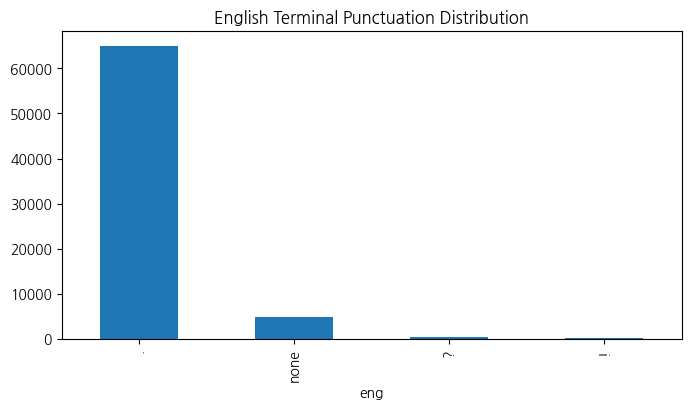

In [19]:
# ============================================================
# [STEP 2-CELL 5] 부정문/종결부호 품질 점검(QA) - 안전 실행 버전
# - 수정:
#   - matplotlib 없으면 bar plot SKIP
#   - df 비면 SKIP
# ============================================================

import re
import numpy as np
import pandas as pd

def get_neg_report(df: pd.DataFrame, seed=42):
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        print("[SKIP] Negation report: df empty/invalid.")
        return

    NEG_PATTERNS = [r"없다", r"않다", r"못하다", r"아니다", r"필요\s*없다"]
    NEG_RE = re.compile("|".join(NEG_PATTERNS))

    clean_shuf = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_total = len(clean_shuf)
    n_val = int(round(n_total * 0.1))

    def calc_ratio(series):
        series = series.fillna("").astype(str)
        return (series.apply(lambda x: bool(NEG_RE.search(x))).mean()) * 100

    print(f"\n[NEGATION REPORT] Overall: {calc_ratio(clean_shuf['kor']):.2f}%")
    if n_val > 0:
        print(f" - Train90 Neg: {calc_ratio(clean_shuf.iloc[n_val:]['kor']):.2f}%")
        print(f" - Val10   Neg: {calc_ratio(clean_shuf.iloc[:n_val]['kor']):.2f}%")
    else:
        print(" - [INFO] dataset too small to split 90/10 meaningfully.")

def terminal_report(series: pd.Series, lang_name: str):
    series = series.fillna("").astype(str).str.strip()
    if len(series) == 0:
        print(f"[SKIP] {lang_name} terminal report: empty.")
        return None

    ends = series.apply(lambda x: x[-1] if len(x) else "none")
    counts = ends.apply(lambda x: x if x in [".", "?", "!"] else "none").value_counts()
    pct = (counts / len(series) * 100).to_dict()
    print(f"\n[{lang_name} TERMINAL PUNCT] {pct}")
    return counts

# 실행
get_neg_report(clean_train_df)

en_counts = terminal_report(clean_train_df["eng"], "ENG")
ko_counts = terminal_report(clean_train_df["kor"], "KOR")

# 시각화(가능할 때만)
if en_counts is not None:
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 4))
        en_counts.plot(kind="bar")
        plt.title("English Terminal Punctuation Distribution")
        plt.show()
    except Exception as e:
        print("[SKIP] matplotlib plot skipped:", str(e))

In [20]:
# ============================================================
# [STEP 2-CELL 5B] Special Token 정합성 검사 - "변수 없으면 SKIP" 안전 버전
# - 목적: <start>/<end>가 vocab에 있고, ids에 실제로 들어가는지 확인
# - 수정:
#   - train_eng_ids / eng_sp 없으면 SKIP
#   - ids가 numpy/tensor여도 안전하게 int 변환
# ============================================================

def check_special_tokens_and_ids(train_eng_ids, eng_sp, n=5):
    if train_eng_ids is None or eng_sp is None:
        print("[SKIP] train_eng_ids or eng_sp is None.")
        return
    if len(train_eng_ids) == 0:
        print("[SKIP] train_eng_ids is empty.")
        return

    start_id = eng_sp.PieceToId("<start>")
    end_id   = eng_sp.PieceToId("<end>")
    pad_id   = eng_sp.pad_id()

    print("[SPECIAL TOKENS]")
    print(" - pad_id  :", pad_id)
    print(" - start_id:", start_id)
    print(" - end_id  :", end_id)

    if start_id < 0 or end_id < 0:
        print("[ERROR] <start>/<end> not found in SentencePiece vocab.")
        return

    print("\n[CHECK train_eng_ids samples]")
    for i in range(min(n, len(train_eng_ids))):
        ids = train_eng_ids[i]
        # numpy/tensor 대비
        ids = [int(x) for x in list(ids)]
        head = ids[:12]
        tail = ids[-12:] if len(ids) >= 12 else ids
        has_start = (len(ids) > 0 and ids[0] == start_id)
        has_end = (end_id in ids)
        print(f" - sample[{i}] len={len(ids)} | starts_with_<start>={has_start} | contains_<end>={has_end}")
        print("   head:", head)
        print("   tail:", tail)

# 실행(있을 때만)
train_eng_ids_obj = globals().get("train_eng_ids", None)
eng_sp_obj = globals().get("eng_sp", None)

if train_eng_ids_obj is None or eng_sp_obj is None:
    print("[SKIP] train_eng_ids or eng_sp not defined yet. Run Step3 tokenization/ids first.")
else:
    check_special_tokens_and_ids(train_eng_ids_obj, eng_sp_obj, n=5)

[SKIP] train_eng_ids or eng_sp not defined yet. Run Step3 tokenization/ids first.


## Step 3. 토큰화 전략 수립 및 SentencePiece 도입
### 목표: UNK 발생률을 0%에 가깝게 억제하고, 한-영 간의 토큰 단위(Granularity)를 일치시켜 어텐션 정렬(Alignment)의 불안정성 해소
#### 1. 토큰화 방향 전환: BPE(Byte Pair Encoding) 기반 SentencePiece
- Mecab(한)과 Split(영) 사용 시, 훈련 데이터에 없는 단어가 나올 경우 unk_rate가 한국어 기준 약 **24.9%**에 달해 정상적인 학습 곤란
#### 2. 어휘 사전(Vocabulary) 구축
- Vocab Size 설정: 한/영 각각 최소 10,000개 이상의 토큰을 확보하여 뉴스 코퍼스의 다양한 표현을 수용.
#### 3. 평가 전용 Detokenize 규칙 추가
#### 4. 토큰 Granularity 불일치 완화 실험(추가)

In [27]:
# ============================================================
# [STEP 3-CELL 1] SentencePiece(BPE) 학습/로드 (start/end/pad 정합성 강화)
# - 핵심 해결:
#   1) <start>/<end>를 user_defined_symbols로 등록 (piece로 유지)
#   2) ids 생성 시 "문자열 결합" 대신 "piece/id 결합"으로 일관성 확보
#   3) kor_sp/eng_sp 로드 후 special id를 즉시 검증
# ============================================================
import re
import os
from pathlib import Path
import sentencepiece as spm
import numpy as np
import pandas as pd

SP_DIR = Path("./spm_tokenizer")
SP_DIR.mkdir(parents=True, exist_ok=True)

train_kor = clean_train_df["kor"].astype(str).tolist()
train_eng = clean_train_df["eng"].astype(str).tolist()
test_kor  = clean_test_df["kor"].astype(str).tolist()
test_eng  = clean_test_df["eng"].astype(str).tolist()

def train_spm(corpus, prefix, vocab_size=16000, char_coverage=1.0):
    """
    - bos/eos는 사용하지 않음 (bos_id=-1, eos_id=-1)
    - <start>/<end>는 user_defined_symbols로 등록
    """
    path = SP_DIR / f"{prefix}_corpus.txt"
    with open(path, "w", encoding="utf-8") as f:
        for line in corpus:
            line = str(line).strip()
            if line:
                f.write(line + "\n")

    spm.SentencePieceTrainer.Train(
        input=str(path),
        model_prefix=str(SP_DIR / prefix),
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=char_coverage,
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
        user_defined_symbols=["<start>", "<end>"],
        # 안정성 옵션(권장)
        normalization_rule_name="nfkc",
        remove_extra_whitespaces=True
    )
    return str(SP_DIR / prefix) + ".model"

# 학습 실행 (필요 시 vocab_size 조정)
kor_model_path = train_spm(train_kor, "kor_bpe16k", vocab_size=16000, char_coverage=0.9995)
eng_model_path = train_spm(train_eng, "eng_bpe16k", vocab_size=16000, char_coverage=1.0)

# 로드
kor_sp = spm.SentencePieceProcessor(); kor_sp.Load(kor_model_path)
eng_sp = spm.SentencePieceProcessor(); eng_sp.Load(eng_model_path)

# special id 즉시 점검
print("[SPM LOADED]")
print(" - KOR vocab:", kor_sp.GetPieceSize(), "pad/unk:", kor_sp.pad_id(), kor_sp.unk_id())
print(" - ENG vocab:", eng_sp.GetPieceSize(), "pad/unk:", eng_sp.pad_id(), eng_sp.unk_id())
print(" - ENG <start> id:", eng_sp.PieceToId("<start>"))
print(" - ENG <end>   id:", eng_sp.PieceToId("<end>"))

assert eng_sp.PieceToId("<start>") >= 0 and eng_sp.PieceToId("<end>") >= 0, \
    "[ERROR] <start>/<end> not in vocab. SPM training config must be fixed."

print("[OK] Step3 SPM training/loading completed.")

[SPM LOADED]
 - KOR vocab: 16000 pad/unk: 0 1
 - ENG vocab: 16000 pad/unk: 0 1
 - ENG <start> id: 2
 - ENG <end>   id: 3
[OK] Step3 SPM training/loading completed.


In [28]:
# ============================================================
# [STEP 3-CELL 2] ids 생성(핵심 수정): "문자열로 붙여 Encode" 금지 → "ID 결합"으로 100% 정합
# - 왜? "<start> " + s + " <end>"는 공백/▁ 규칙 때문에 미묘한 불일치가 생길 수 있음
# - 해결: ids = [start_id] + EncodeAsIds(s) + [end_id]
# ============================================================
def encode_with_start_end(sp, sentence: str, start_piece="<start>", end_piece="<end>"):
    start_id = sp.PieceToId(start_piece)
    end_id   = sp.PieceToId(end_piece)
    assert start_id >= 0 and end_id >= 0, "start/end piece not found in vocab"
    core = sp.EncodeAsIds(str(sentence))
    return [start_id] + core + [end_id]

# 최종 ids 생성
train_kor_ids = [kor_sp.EncodeAsIds(s) for s in train_kor]
test_kor_ids  = [kor_sp.EncodeAsIds(s) for s in test_kor]

train_eng_ids = [encode_with_start_end(eng_sp, s) for s in train_eng]
test_eng_ids  = [encode_with_start_end(eng_sp, s) for s in test_eng]

print("[OK] train/test ids generated with strict <start>/<end> wrapping.")

[OK] train/test ids generated with strict <start>/<end> wrapping.


In [29]:
# ============================================================
# [STEP 3-CELL 3] <start>/<end> 포함률 100% + 위치 검증 + 샘플 확인
# - 학습 붕괴(짧게 끝남/반복)의 1순위 원인: special token 불일치
# ============================================================
import random

def check_start_end_coverage(ids_list, sp, name="ENG_IDS", n_show=5):
    start_id = sp.PieceToId("<start>")
    end_id   = sp.PieceToId("<end>")

    total = len(ids_list)
    starts_ok = sum(1 for ids in ids_list if len(ids) > 0 and ids[0] == start_id)
    ends_ok   = sum(1 for ids in ids_list if len(ids) > 1 and ids[-1] == end_id)
    contains_end = sum(1 for ids in ids_list if end_id in ids)

    print(f"\n[{name}] total={total:,}")
    print(f" - starts_with_<start>: {starts_ok}/{total} ({starts_ok/total*100:.2f}%)")
    print(f" - ends_with_<end>    : {ends_ok}/{total} ({ends_ok/total*100:.2f}%)")
    print(f" - contains_<end>     : {contains_end}/{total} ({contains_end/total*100:.2f}%)")

    assert starts_ok == total, "[ERROR] Some sequences do NOT start with <start>"
    assert ends_ok == total,   "[ERROR] Some sequences do NOT end with <end>"

    # 샘플 출력
    idxs = random.sample(range(total), k=min(n_show, total))
    for i in idxs:
        ids = ids_list[i]
        head = ids[:12]
        tail = ids[-12:] if len(ids) >= 12 else ids
        print(f" - sample[{i}] len={len(ids)} head={head} tail={tail}")
        # 디코드(특수토큰 포함하면 보이게)
        pieces = sp.IdToPiece(head[0])
    print("[OK] <start>/<end> coverage validated.")

check_start_end_coverage(train_eng_ids, eng_sp, name="TRAIN_ENG_IDS", n_show=3)
check_start_end_coverage(test_eng_ids,  eng_sp, name="TEST_ENG_IDS",  n_show=3)


[TRAIN_ENG_IDS] total=70,563
 - starts_with_<start>: 70563/70563 (100.00%)
 - ends_with_<end>    : 70563/70563 (100.00%)
 - contains_<end>     : 70563/70563 (100.00%)
 - sample[14592] len=17 head=[2, 354, 219, 15974, 9450, 1074, 156, 649, 65, 9, 364, 460] tail=[1074, 156, 649, 65, 9, 364, 460, 28, 788, 436, 15973, 3]
 - sample[3278] len=30 head=[2, 1745, 472, 238, 627, 2264, 79, 65, 3803, 7301, 15974, 43] tail=[404, 336, 312, 1912, 89, 15978, 15959, 2670, 108, 374, 15973, 3]
 - sample[36048] len=18 head=[2, 90, 15956, 2253, 85, 350, 925, 1460, 962, 5024, 1298, 31] tail=[925, 1460, 962, 5024, 1298, 31, 1406, 89, 207, 185, 15973, 3]
[OK] <start>/<end> coverage validated.

[TEST_ENG_IDS] total=1,798
 - starts_with_<start>: 1798/1798 (100.00%)
 - ends_with_<end>    : 1798/1798 (100.00%)
 - contains_<end>     : 1798/1798 (100.00%)
 - sample[501] len=30 head=[2, 3435, 35, 23, 14385, 43, 7246, 9952, 61, 502, 2517, 9] tail=[4253, 1290, 43, 1103, 31, 1386, 28, 43, 2509, 1026, 15973, 3]
 - samp

In [30]:
# ============================================================
# [STEP 3-CELL 4] 길이 통계 + "학습 max_len(예: 60)" 기준 Truncation 위험도 측정
# - 핵심: Step2는 공백 40 제한이지만, Step3는 subword 길이가 실제 학습 길이
# - Step4 Dataset에서 max_len=60이면, 60 초과 비율이 높을수록 EOS 학습 붕괴 위험 ↑
# ============================================================
import numpy as np

def len_stats(ids_list, name="IDS"):
    lens = np.array([len(x) for x in ids_list], dtype=np.int32)
    return {
        "name": name,
        "n": int(lens.size),
        "mean": float(lens.mean()),
        "p50": float(np.percentile(lens, 50)),
        "p90": float(np.percentile(lens, 90)),
        "p95": float(np.percentile(lens, 95)),
        "p99": float(np.percentile(lens, 99)),
        "max": int(lens.max()),
    }

def truncation_risk(ids_list, max_len=60, name="IDS"):
    lens = np.array([len(x) for x in ids_list], dtype=np.int32)
    over = (lens > max_len)
    pct = over.mean() * 100
    print(f"[TRUNCATION RISK] {name}: max_len={max_len} | over={over.sum()}/{len(lens)} ({pct:.2f}%)")
    return float(pct)

# 통계 출력
for d in [
    len_stats(train_kor_ids, "TRAIN_KOR"),
    len_stats(train_eng_ids, "TRAIN_ENG"),
    len_stats(test_kor_ids,  "TEST_KOR"),
    len_stats(test_eng_ids,  "TEST_ENG"),
]:
    print(f"[{d['name']}] n={d['n']:,} mean={d['mean']:.1f} p95={d['p95']:.0f} p99={d['p99']:.0f} max={d['max']}")

# Step4에서 max_len=60 쓴다면 위험도 측정
trunc_train_eng = truncation_risk(train_eng_ids, max_len=60, name="TRAIN_ENG")
trunc_train_kor = truncation_risk(train_kor_ids, max_len=60, name="TRAIN_KOR")

[TRAIN_KOR] n=70,563 mean=25.3 p95=44 p99=55 max=109
[TRAIN_ENG] n=70,563 mean=28.5 p95=47 p99=54 max=78
[TEST_KOR] n=1,798 mean=26.7 p95=46 p99=57 max=78
[TEST_ENG] n=1,798 mean=29.6 p95=48 p99=55 max=65
[TRUNCATION RISK] TRAIN_ENG: max_len=60 | over=125/70563 (0.18%)
[TRUNCATION RISK] TRAIN_KOR: max_len=60 | over=300/70563 (0.43%)


In [31]:
# ============================================================
# [STEP 3-CELL 5] (필수) Truncation 발생 샘플 추출/가시화: "잘린 문장"이 얼마나 심각한지 확인
# - 잘린 문장은 끝(<end>)이 Dataset 슬라이싱으로 잘려서 사라질 수 있음
# - 결과: 모델이 EOS를 못 배워 "짧게 끝남/반복"으로 이어짐
# ============================================================
import random

def decode_ids_with_special(sp, ids):
    # 특수토큰도 보이게 piece로 변환해 확인
    return sp.DecodePieces([sp.IdToPiece(int(i)) for i in ids])

def show_long_samples(corpus, ids_list, sp, max_len=60, n=5, seed=42, title="LONG SAMPLES"):
    random.seed(seed)
    idxs = [i for i, ids in enumerate(ids_list) if len(ids) > max_len]
    print(f"\n[{title}] over max_len={max_len}: {len(idxs)}/{len(ids_list)}")
    if not idxs:
        print("[OK] No truncation risk samples.")
        return
    pick = random.sample(idxs, k=min(n, len(idxs)))
    rows = []
    for i in pick:
        ids = ids_list[i]
        rows.append({
            "idx": i,
            "len": len(ids),
            "orig": corpus[i][:200],
            "decoded_head": decode_ids_with_special(sp, ids[:max_len]),
            "decoded_tail": decode_ids_with_special(sp, ids[-max_len:]),
        })
    display(pd.DataFrame(rows))

# 영어 타겟에서 truncation 위험 샘플 확인
show_long_samples(train_eng, train_eng_ids, eng_sp, max_len=60, n=5, title="TRAIN_ENG TRUNCATION CANDIDATES")


[TRAIN_ENG TRUNCATION CANDIDATES] over max_len=60: 125/70563


,idx,len,orig,decoded_head,decoded_tail
0,38020,65,"""cyprus packs a huge amount of monuments in su...","<start> ""cyprus packs a huge amount of monumen...",packs a huge amount of monuments in such a sma...
1,9458,61,"dr. christiane northrup, an obstetrician-gynec...","<start> dr. christiane northrup, an obstetrici...","dr. christiane northrup, an obstetrician-gynec..."
2,2302,67,the 128-million-year-old animal called microra...,<start> the 128-million-year-old animal called...,"-old animal called microraptor gui, in honor o..."
3,44312,68,the other guild nominees were bill condon for ...,<start> the other guild nominees were bill con...,"on for the musical ""dreamgirls,"" jonathan dayt..."
4,17589,62,"""i think she was kind and sweet, not like a te...","<start> ""i think she was kind and sweet, not l...","i think she was kind and sweet, not like a ter..."


In [32]:
# ============================================================
# [STEP 3-CELL 6] Detokenize(평가용) 안정화: ids → 문자열 (start/end/pad 제거 후 DecodeIds)
# - 모델 출력 후 평가/샘플 출력에서 "특수토큰/패딩"이 섞여 출력되는 문제 방지
# ============================================================
import re

def detokenize_eval(sp, ids_or_tokens):
    special_symbols = {"<start>", "<end>", "<pad>", "</s>", "<s>"}

    # tokens list(str) 입력
    if len(ids_or_tokens) > 0 and isinstance(ids_or_tokens[0], str):
        filtered = [t for t in ids_or_tokens if t not in special_symbols]
        return sp.DecodePieces(filtered).strip()

    # ids list(int) 입력
    start_id = sp.PieceToId("<start>")
    end_id   = sp.PieceToId("<end>")
    pad_id   = sp.pad_id()

    filtered_ids = []
    for i in ids_or_tokens:
        ii = int(i)
        if ii in (start_id, end_id, pad_id) or ii < 0:
            continue
        filtered_ids.append(ii)

    decoded = sp.DecodeIds(filtered_ids)
    return re.sub(r"\s+", " ", decoded).strip()

# quick sanity
sample_idx = 0
print("[DETOKENIZE CHECK]")
print(" - 원문:", train_eng[sample_idx][:120])
print(" - 복원:", detokenize_eval(eng_sp, train_eng_ids[sample_idx])[:120])
print("[OK] detokenize_eval ready.")

[DETOKENIZE CHECK]
 - 원문: much of personal computing is about "can you top this?"
 - 복원: much of personal computing is about "can you top this?"
[OK] detokenize_eval ready.


In [33]:
# ============================================================
# [STEP 3-CELL 7] (선택) ids 저장: "중간에 강제로 넣은 값" 방지용 재현성 확보
# - 목적: Step3 결과(ids, spm 모델)를 고정시켜 Step4/5에서 흔들리지 않게 함
# ============================================================
import json

OUT_DIR = Path("./artifacts_step3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_ids(path, ids_list):
    with open(path, "w", encoding="utf-8") as f:
        for ids in ids_list:
            f.write(" ".join(map(str, ids)) + "\n")

save_ids(OUT_DIR / "train_kor_ids.txt", train_kor_ids)
save_ids(OUT_DIR / "train_eng_ids.txt", train_eng_ids)
save_ids(OUT_DIR / "test_kor_ids.txt",  test_kor_ids)
save_ids(OUT_DIR / "test_eng_ids.txt",  test_eng_ids)

meta = {
    "kor_model": str(kor_model_path),
    "eng_model": str(eng_model_path),
    "kor_vocab": int(kor_sp.GetPieceSize()),
    "eng_vocab": int(eng_sp.GetPieceSize()),
    "eng_start_id": int(eng_sp.PieceToId("<start>")),
    "eng_end_id": int(eng_sp.PieceToId("<end>")),
    "pad_id": int(eng_sp.pad_id()),
}
with open(OUT_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"[OK] Step3 artifacts saved to: {OUT_DIR.resolve()}")
print(meta)

[OK] Step3 artifacts saved to: D:\PyProject\AIFFEL_AI\LLM\artifacts_step3
{'kor_model': 'spm_tokenizer\\kor_bpe16k.model', 'eng_model': 'spm_tokenizer\\eng_bpe16k.model', 'kor_vocab': 16000, 'eng_vocab': 16000, 'eng_start_id': 2, 'eng_end_id': 3, 'pad_id': 0}


### Step 4. 모델 설계 및 학습 파이프라인 구축
#### 1. 데이터 파이프라인 (Dataset & DataLoader)
- Dynamic Padding: 배치 안에서 가장 긴 문장 길이에 맞춰 패딩하는 것
- <start>/<end> 보존 truncation: Max Length 60 적용
- Teacher Forcing은 학습 시점에서 디코더의 다음 입력으로 모델의 이전 예측값(ŷ_{t-1})이 아니라, 실제 정답(y_{t-1}) 토큰을 사용하는 방법
- Teacher Forcing Shift 정합: 입력/정답 한 칸 이동 일치 : dec_out[t] = dec_in[t+1]
#### 2. 모델 아키텍처 라인업
- Vanilla Seq2Seq: Context Vector 하나에 모든 정보를 압축하는 기본 구조
- Bahdanau Attention: 인코더의 모든 시점 상태를 참고하는 가산(Additive) 어텐션
- Luong Attention: 연산 효율이 높은 점곱(Dot-product) 기반 어텐션 및 Global/Local 변형
#### 3. 학습 안정성 및 붕괴 방지 전략 
 - Softmax Dim: Attention Weight 계산 시 Source 축($dim=-1$) 적용 확인
 - Masking: PAD 토큰 위치에 $-inf$를 부여하여 점수 왜곡 방지
- Row-sum Check: 각 타겟 스텝의 어텐션 합이 $1.0$에 수렴하는지 모니터링
#### 4. 정칙화(Regularization): 
- Dropout 0.3, Label Smoothing 0.1, Gradient Clipping 1.0 적용

In [34]:
# ============================================================
# [STEP 4-CELL 1] 모델 아키텍처 정의 (Encoder, Decoder, Attention)
# - 변경 요약:
#   * mask dtype을 bool로 강제 (안전)
#   * src_len은 일단 unused(추후 pack_padded_sequence로 확장 가능)
# ============================================================

import torch
import torch.nn as nn
import random

# 1. 인코더 (GRU)
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        emb = self.dropout(self.embedding(src))          # (B, S, E)
        outputs, hidden = self.rnn(emb)                  # outputs: (B, S, H), hidden: (1, B, H)
        return outputs, hidden.squeeze(0)                # (B,S,H), (B,H)


# 2. 어텐션 레이어 (Bahdanau & Luong)
class Attention(nn.Module):
    def __init__(self, hid_dim, attn_type="bahdanau"):
        super().__init__()
        self.attn_type = attn_type
        if attn_type == "bahdanau":
            self.W = nn.Linear(hid_dim * 2, hid_dim)
            self.v = nn.Linear(hid_dim, 1, bias=False)
        else:  # luong
            self.wa = nn.Linear(hid_dim, hid_dim)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        """
        decoder_hidden: (B, H)
        encoder_outputs: (B, S, H)
        mask: (B, S)  True=valid, False=pad
        """
        if mask.dtype != torch.bool:
            mask = mask.bool()

        if self.attn_type == "bahdanau":
            # (B,1,H) -> (B,S,H)
            repeat_dec_hidden = decoder_hidden.unsqueeze(1).expand(-1, encoder_outputs.size(1), -1)
            energy = torch.tanh(self.W(torch.cat((repeat_dec_hidden, encoder_outputs), dim=2)))  # (B,S,H)
            score = self.v(energy).squeeze(2)  # (B,S)
        else:
            # score = H_enc · W_a(h_dec)
            score = torch.bmm(encoder_outputs, self.wa(decoder_hidden).unsqueeze(2)).squeeze(2)  # (B,S)

        # PAD 마스킹
        score = score.masked_fill(~mask, -1e10)

        # Softmax dim은 source축(-1)이어야 함
        attn_weights = torch.softmax(score, dim=-1)  # (B,S)

        # context = Σ a_t * h_t
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (B,H)
        return context, attn_weights


# 3. 바닐라 디코더 (Attention 없음)
class DecoderVanilla(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_step, hidden):
        """
        input_step: (B,1)
        hidden: (B,H)
        """
        emb = self.dropout(self.embedding(input_step))        # (B,1,E)
        output, hidden = self.rnn(emb, hidden.unsqueeze(0))   # output:(B,1,H), hidden:(1,B,H)
        logits = self.fc_out(output.squeeze(1))               # (B,V)
        return logits, hidden.squeeze(0), None


# 4. 어텐션 디코더
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, attn_type="bahdanau", dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.attn = Attention(hid_dim, attn_type)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_step, hidden, encoder_outputs, mask):
        """
        input_step: (B,1)
        hidden: (B,H)
        encoder_outputs: (B,S,H)
        mask: (B,S)
        """
        emb = self.dropout(self.embedding(input_step))         # (B,1,E)
        context, attn = self.attn(hidden, encoder_outputs, mask)   # (B,H), (B,S)
        rnn_input = torch.cat((emb, context.unsqueeze(1)), dim=2)  # (B,1,E+H)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))  # output:(B,1,H), hidden:(1,B,H)
        logits = self.fc_out(output.squeeze(1))                # (B,V)
        return logits, hidden.squeeze(0), attn


# 5. Seq2Seq 조립
# 5. Seq2Seq 조립 (PATCH: attn_all 누적 + per-sample teacher forcing)
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_len, dec_in, teacher_forcing_ratio=0.5, return_attn=True):
        """
        src:    (B,S)
        src_len:(B,)  현재는 사용 안 함(추후 pack에 사용 가능)
        dec_in: (B,T)  첫 토큰은 <start> 이어야 함
        outputs:(B,T,V)  각 t는 dec_out[:,t]에 대한 로짓
        attn_all:(B,T,S) (attention decoder일 때만) / vanilla면 None
        """
        B = src.size(0)
        T = dec_in.size(1)
        V = self.decoder.fc_out.out_features

        outputs = torch.zeros(B, T, V, device=self.device)

        encoder_outputs, hidden = self.encoder(src)  # (B,S,H), (B,H)

        # PAD 마스크: True=valid (shape: B,S)
        mask = (src != self.encoder.pad_id).bool()

        input_step = dec_in[:, 0].unsqueeze(1)  # (B,1) = <start>

        # ✅ attention 전체 누적 버퍼
        attn_steps = [] if (return_attn and (not isinstance(self.decoder, DecoderVanilla))) else None

        for t in range(T):
            if isinstance(self.decoder, DecoderVanilla):
                logits, hidden, attn = self.decoder(input_step, hidden)  # attn=None
            else:
                logits, hidden, attn = self.decoder(input_step, hidden, encoder_outputs, mask)  # attn:(B,S)

            outputs[:, t] = logits

            # ✅ (B,S) -> (B,1,S)로 누적
            if attn_steps is not None:
                attn_steps.append(attn.unsqueeze(1))

            top1 = logits.argmax(1)  # (B,)

            # ✅ per-sample teacher forcing (배치별로 독립)
            if teacher_forcing_ratio >= 1.0:
                use_teacher = torch.ones(B, dtype=torch.bool, device=self.device)
            elif teacher_forcing_ratio <= 0.0:
                use_teacher = torch.zeros(B, dtype=torch.bool, device=self.device)
            else:
                use_teacher = (torch.rand(B, device=self.device) < teacher_forcing_ratio)

            if t < T - 1:
                gold_next = dec_in[:, t+1]  # (B,)
                next_token = torch.where(use_teacher, gold_next, top1)  # (B,)
                input_step = next_token.unsqueeze(1)  # (B,1)

        attn_all = None
        if attn_steps is not None and len(attn_steps) > 0:
            attn_all = torch.cat(attn_steps, dim=1)  # (B,T,S)

        return outputs, attn_all

print("[OK] Step4-CELL1 Model classes ready.")

[OK] Step4-CELL1 Model classes ready.


In [35]:
# ============================================================
# [STEP 4-CELL 2 - FIXED] 데이터 파이프라인 및 모델 생성
# (max_len=60, <start>/<end> 보존, train/val split, test 격리)
# - 변경 요약(당신 코드 베이스 유지 + 안정화):
#   1) ✅ val_loader는 train에서 split한 val 사용 (test는 test_loader로 격리)
#   2) ✅ trg truncation 시 "첫 <end>까지만" 유지하여 조기종료 학습 오염 방지
#   3) ✅ 배치 스모크 테스트는 train/val/test 각각 수행
# ============================================================

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np

# ---- 사전 조건 체크 ----
assert "kor_sp" in globals() and "eng_sp" in globals(), "kor_sp/eng_sp가 먼저 로드되어 있어야 합니다."
assert "train_kor_ids" in globals() and "train_eng_ids" in globals(), "train_kor_ids/train_eng_ids가 먼저 있어야 합니다."
assert "test_kor_ids" in globals() and "test_eng_ids" in globals(), "test_kor_ids/test_eng_ids가 먼저 있어야 합니다."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[OK] device:", device)

PAD_KO = int(kor_sp.pad_id())
PAD_EN = int(eng_sp.pad_id())
START_EN = int(eng_sp.PieceToId("<start>"))
END_EN   = int(eng_sp.PieceToId("<end>"))

assert PAD_KO >= 0 and PAD_EN >= 0, "pad_id 확인 필요"
assert START_EN >= 0 and END_EN >= 0, "<start>/<end> 가 vocab에 없음 (SPM 학습 옵션 확인 필요)"

MAX_LEN = 60   # ✅ 고정 (Step3 기반)
BATCH_SIZE = 64
VAL_RATIO = 0.05   # ✅ 추천 0.05 (안정적). 원하면 0.1로.

# -----------------------------
# Truncation utils
# -----------------------------
def truncate_src(ids, max_len=MAX_LEN):
    # src는 특수토큰 강제 규칙이 없으면 단순 자르기
    if len(ids) <= max_len:
        return ids
    return ids[:max_len]

def truncate_trg_keep_start_end(ids, start_id=START_EN, end_id=END_EN, max_len=MAX_LEN):
    """
    trg는 항상:
      - 첫 토큰 <start>
      - 마지막(비-pad) 토큰 <end>
    를 보장.

    ✅ 추가 안정화:
      - "첫 <end>"까지만 유효로 간주하여 그 뒤 토큰은 제거 (데이터 깨짐/조기종료 오염 방지)
      - max_len 초과 시: 앞에서 max_len-1개 + 마지막을 <end>로 강제
    """
    if ids is None or len(ids) == 0:
        return [start_id, end_id]

    # 방어: start/end 보정
    if ids[0] != start_id:
        ids = [start_id] + list(ids)
    else:
        ids = list(ids)

    # end가 없으면 붙임
    if ids[-1] != end_id:
        ids.append(end_id)

    # ✅ 첫 end까지만 유지 (중간 end 이후 제거)
    # end는 반드시 하나만 남도록
    try:
        first_end = ids.index(end_id)
        ids = ids[:first_end + 1]
    except ValueError:
        ids.append(end_id)

    # 길이 제한
    if len(ids) <= max_len:
        return ids

    cut = ids[:max_len]
    cut[0]  = start_id
    cut[-1] = end_id
    return cut

# -----------------------------
# Dataset
# -----------------------------
class TranslationDataset(Dataset):
    def __init__(self, src_ids, trg_ids, max_len=MAX_LEN):
        self.max_len = int(max_len)
        self.src_data = []
        self.trg_data = []

        for s_ids, t_ids in zip(src_ids, trg_ids):
            s = truncate_src(s_ids, self.max_len)
            t = truncate_trg_keep_start_end(t_ids, START_EN, END_EN, self.max_len)

            self.src_data.append(torch.tensor(s, dtype=torch.long))
            self.trg_data.append(torch.tensor(t, dtype=torch.long))

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return self.src_data[idx], self.trg_data[idx]

# -----------------------------
# Collate (dynamic padding + TF shift)
# -----------------------------
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src = pad_sequence(src_batch, batch_first=True, padding_value=PAD_KO)  # (B,S)
    tgt = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_EN)  # (B,T_full)

    src_len = (src != PAD_KO).sum(dim=1)  # (B,)

    # tgt: [<start> ... <end> pad pad ...]
    dec_in  = tgt[:, :-1]  # (B,T-1) starts with <start>
    dec_out = tgt[:,  1:]  # (B,T-1) ends with <end> in valid span

    return src, src_len, dec_in, dec_out

# ============================================================
# ✅ 핵심 수정: train에서 val split, test는 격리
# ============================================================
N = len(train_kor_ids)
idx = np.arange(N)
rng = np.random.default_rng(42)
rng.shuffle(idx)

n_val = int(round(N * VAL_RATIO))
val_idx = idx[:n_val]
trn_idx = idx[n_val:]

train_kor_ids_tr = [train_kor_ids[i] for i in trn_idx]
train_eng_ids_tr = [train_eng_ids[i] for i in trn_idx]
val_kor_ids      = [train_kor_ids[i] for i in val_idx]
val_eng_ids      = [train_eng_ids[i] for i in val_idx]

print(f"[SPLIT] train={len(train_kor_ids_tr):,} | val={len(val_kor_ids):,} | test(final)={len(test_kor_ids):,}")

# -----------------------------
# Loaders
# -----------------------------
train_loader = DataLoader(
    TranslationDataset(train_kor_ids_tr, train_eng_ids_tr, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)

val_loader = DataLoader(
    TranslationDataset(val_kor_ids, val_eng_ids, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

# ✅ test_loader: 최종 평가 전용 (Step5 학습루프에서는 사용 금지)
test_loader = DataLoader(
    TranslationDataset(test_kor_ids, test_eng_ids, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"[OK] DataLoader Ready | MAX_LEN={MAX_LEN}")
print(f" - KOR vocab={kor_sp.GetPieceSize():,} pad={PAD_KO}")
print(f" - ENG vocab={eng_sp.GetPieceSize():,} pad={PAD_EN} start={START_EN} end={END_EN}")

# ------------------------------------------------------------
# ✅ 배치 검증(스모크 테스트)
# ------------------------------------------------------------
def batch_sanity_check(loader, name="train_loader", n_batches=2):
    it = iter(loader)
    for b in range(n_batches):
        src, src_len, dec_in, dec_out = next(it)

        assert src.dim() == 2 and dec_in.dim() == 2 and dec_out.dim() == 2
        assert dec_in.shape == dec_out.shape, "dec_in/dec_out 길이 불일치"
        assert src.shape[0] == dec_in.shape[0], "batch size 불일치"

        # start token check
        starts_ok = (dec_in[:, 0] == START_EN).float().mean().item() * 100.0

        # end token check (valid span에서 end 존재)
        has_end = []
        for i in range(dec_out.size(0)):
            # dec_out valid len = count(non-pad in tgt) - 1
            tgt_nonpad = int((torch.cat([dec_in[i:i+1, :1], dec_out[i:i+1]], dim=1) != PAD_EN).sum().item())
            tgt_nonpad = max(tgt_nonpad, 2)
            valid = dec_out[i, :tgt_nonpad-1]
            has_end.append(bool((valid == END_EN).any().item()))
        ends_ok = (sum(has_end) / len(has_end)) * 100.0

        assert src.size(1) <= MAX_LEN, "src padded len이 MAX_LEN 초과"
        assert (dec_in.size(1) + 1) <= MAX_LEN, "tgt padded len이 MAX_LEN 초과"

        print(f"[SANITY:{name}] batch{b} | src={tuple(src.shape)} dec_in={tuple(dec_in.shape)}")
        print(f" - dec_in starts_with <start>: {starts_ok:.2f}%")
        print(f" - dec_out contains <end> in valid span: {ends_ok:.2f}%")

batch_sanity_check(train_loader, "train_loader", n_batches=2)
batch_sanity_check(val_loader,   "val_loader",   n_batches=1)
batch_sanity_check(test_loader,  "test_loader",  n_batches=1)

# ------------------------------------------------------------
# 모델 빌드
# ------------------------------------------------------------
def build_model(attn_type="bahdanau", is_vanilla=False):
    enc = Encoder(kor_sp.GetPieceSize(), 256, 512, PAD_KO)
    if is_vanilla:
        dec = DecoderVanilla(eng_sp.GetPieceSize(), 256, 512, PAD_EN)
    else:
        dec = Decoder(eng_sp.GetPieceSize(), 256, 512, PAD_EN, attn_type=attn_type)
    return Seq2Seq(enc, dec, device).to(device)

models = {
    "vanilla": build_model(is_vanilla=True),
    "bahdanau": build_model(attn_type="bahdanau"),
    "luong": build_model(attn_type="luong"),
}
print("[OK] 3 models ready:", list(models.keys()))

[OK] device: cuda
[SPLIT] train=67,035 | val=3,528 | test(final)=1,798
[OK] DataLoader Ready | MAX_LEN=60
 - KOR vocab=16,000 pad=0
 - ENG vocab=16,000 pad=0 start=2 end=3
[SANITY:train_loader] batch0 | src=(64, 57) dec_in=(64, 47)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:train_loader] batch1 | src=(64, 57) dec_in=(64, 59)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:val_loader] batch0 | src=(64, 60) dec_in=(64, 53)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:test_loader] batch0 | src=(64, 57) dec_in=(64, 58)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[OK] 3 models ready: ['vanilla', 'bahdanau', 'luong']


## Step 5 모델 학습 및 실시간 성능 모니터링
#### 목표: 동일 조건 하에 3종 모델을 학습하며, 수치 지표(Loss)와 정성 지표(Attention Map)의 괴리를 실시간으로 추적하고 학습 안정성을 극대화
#### 1. 학습 고도화 전략
- Early Stopping (Loss 기준): BLEU의 변동성 문제를 피하기 위해 Validation Loss를 기준으로 삼되, 충분한 학습을 위해 Patience를 10~15로 넉넉히 설정
- 체크포인트 이중화: 최저 Loss를 기록한 best_model.pt와 학습 중단 시 복구를 위한 last_model.pt를 동시에 관리
- 붕괴 탐지 로그: Luong Attention이 특정 토큰(예: 마침표)에만 쏠리는 현상을 Entropy와 Max Attention Value로 실시간 감시
#### 2. 정성적 추적 (Subset Monitoring)
- 고정 샘플링: 매 Epoch마다 (짧은 문장 / 부정문 / 고유명사)가 포함된 특정 Subset의 번역 결과와
- Attention Map을 출력하여 "점수와 시각화의 괴리"를 정성적으로 분석

In [47]:
# ============================================================
# [STEP 5-CELL 1-ENGINE] 통합 학습/검증/추론 엔진 (정의 고정 셀)
# ============================================================

import numpy as np
import torch
import torch.nn as nn

# ---------- Greedy Decode ----------
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=60):
    """
    src_ids: list[int] (KOR SPM ids, <start>/<end> 없음)
    return:
      dec_ids: list[int] (ENG ids, <start> 포함, <end> 포함될 수 있음)
      attn_map: np.ndarray (T,S) 또는 None
    """
    model.eval()

    src = torch.tensor([src_ids], dtype=torch.long, device=device)  # (1,S)
    src_mask = (src != kor_sp.pad_id()).bool()                      # (1,S) True=valid

    encoder_outputs, hidden = model.encoder(src)                    # (1,S,H), (1,H)

    start_id = int(eng_sp.PieceToId("<start>"))
    end_id   = int(eng_sp.PieceToId("<end>"))
    if start_id < 0 or end_id < 0:
        raise RuntimeError("ENG SPM vocab에 <start>/<end>가 없습니다. Step3 special tokens 확인 필요.")

    dec_ids = [start_id]
    attn_steps = []

    for _ in range(max_len):
        curr = torch.tensor([[dec_ids[-1]]], dtype=torch.long, device=device)  # (1,1)

        if isinstance(model.decoder, DecoderVanilla):
            logits, hidden, attn = model.decoder(curr, hidden)                 # attn=None
        else:
            logits, hidden, attn = model.decoder(curr, hidden, encoder_outputs, src_mask)  # attn:(1,S)

        next_id = int(logits.argmax(-1).item())
        dec_ids.append(next_id)

        if attn is not None:
            attn_steps.append(attn.squeeze(0).detach().cpu().numpy())          # (S,)

        if next_id == end_id:
            break

    attn_map = np.stack(attn_steps, axis=0) if len(attn_steps) > 0 else None   # (T,S)
    return dec_ids, attn_map


def sample_translate(model, kor_sentence, max_len=60):
    """
    고정 샘플 번역(정성 모니터링)
    """
    src_ids = kor_sp.EncodeAsIds(kor_sentence)
    pred_ids, attn = greedy_decode(model, src_ids, max_len=max_len)
    return detokenize_eval(eng_sp, pred_ids), attn


# ---------- Attention Collapse Metrics ----------
def _attn_entropy_from_probs(attn_probs: torch.Tensor, eps=1e-10) -> torch.Tensor:
    """
    attn_probs: (B,T,S), already softmaxed
    return: (B,T) entropy
    """
    return -torch.sum(attn_probs * torch.log(attn_probs + eps), dim=-1)

@torch.no_grad()
def compute_attn_metrics(attn_all: torch.Tensor) -> dict:
    """
    attn_all: (B,T,S) or None
    returns dict with entropy / max_attn / row_sum_err / collapse_ratio
    """
    if attn_all is None:
        return {"attn_entropy": None, "attn_max": None, "row_sum_err": None, "collapse_ratio": None}

    # row sum should be ~1.0
    row_sum = attn_all.sum(dim=-1)                       # (B,T)
    row_sum_err = (row_sum - 1.0).abs().mean().item()

    ent = _attn_entropy_from_probs(attn_all).mean().item()
    max_attn = attn_all.max(dim=-1).values.mean().item() # (B,T)->mean

    # 붕괴 감지: max attn > 0.95 비율
    collapse_ratio = (attn_all.max(dim=-1).values > 0.95).float().mean().item()

    return {
        "attn_entropy": float(ent),
        "attn_max": float(max_attn),
        "row_sum_err": float(row_sum_err),
        "collapse_ratio": float(collapse_ratio),
    }


# ---------- Train / Validate ----------
def train_one_epoch(model, loader, optimizer, criterion, tf_ratio=1.0, grad_clip=1.0):
    model.train()
    total_loss = 0.0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits, _attn_all = model(src, src_len, dec_in, teacher_forcing_ratio=tf_ratio)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += float(loss.item())

    return total_loss / max(1, len(loader))


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, tf_ratio_val=1.0):
    """
    tf_ratio_val:
      - 당신 정책 유지: 기본 1.0 (teacher-forced loss로 early stopping)
      - 대신, two-track에서 free-run은 별도 트랙으로 검증
    """
    model.eval()
    total_loss = 0.0

    ent_sum, max_sum, rowerr_sum, coll_sum, attn_batches = 0.0, 0.0, 0.0, 0.0, 0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        logits, attn_all = model(src, src_len, dec_in, teacher_forcing_ratio=tf_ratio_val)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )
        total_loss += float(loss.item())

        m = compute_attn_metrics(attn_all)
        if m["attn_entropy"] is not None:
            ent_sum += m["attn_entropy"]
            max_sum += m["attn_max"]
            rowerr_sum += m["row_sum_err"]
            coll_sum += m["collapse_ratio"]
            attn_batches += 1

    val_loss = total_loss / max(1, len(loader))
    if attn_batches > 0:
        attn_metrics = {
            "attn_entropy": ent_sum / attn_batches,
            "attn_max": max_sum / attn_batches,
            "row_sum_err": rowerr_sum / attn_batches,
            "collapse_ratio": coll_sum / attn_batches,
        }
    else:
        attn_metrics = {
            "attn_entropy": None,
            "attn_max": None,
            "row_sum_err": None,
            "collapse_ratio": None,
        }

    return val_loss, attn_metrics


print("[OK] Step5-CELL1 ENGINE defined: greedy_decode / sample_translate / compute_attn_metrics / train_one_epoch / validate_one_epoch")

[OK] Step5-CELL1 ENGINE defined: greedy_decode / sample_translate / compute_attn_metrics / train_one_epoch / validate_one_epoch


In [49]:
# ============================================================
# [STEP 5-CELL 1-SMOKE] "정의가 됐는지" 먼저 확인 (여기서 안 되면 다음으로 못 감)
# ============================================================

need = ["greedy_decode", "sample_translate", "compute_attn_metrics", "train_one_epoch", "validate_one_epoch"]
missing = [k for k in need if k not in globals()]

print("[CHECK] Step5 functions in globals()")
for k in need:
    print(f" - {k}: {'OK' if k in globals() else 'MISSING'}")

if missing:
    raise RuntimeError(f"Step5 엔진 함수가 누락되었습니다: {missing}  (위 ENGINE 셀부터 다시 실행)")
print("[OK] Step5 엔진 함수 정의 확인 완료.")

[CHECK] Step5 functions in globals()
 - greedy_decode: OK
 - sample_translate: OK
 - compute_attn_metrics: OK
 - train_one_epoch: OK
 - validate_one_epoch: OK
[OK] Step5 엔진 함수 정의 확인 완료.


In [51]:
# ============================================================
# [STEP 5-CELL 1-VERIFY] two-track 적용 확인 + test 잔재 점검 + attn 확률 점검
# - 목적:
#   1) Track-A: val_loss는 TF=1.0 teacher-forced 로스(당신 정책)
#   2) Track-B: free-run은 greedy_decode로 별도 모니터링(괴리 감시)
#   3) val_loader가 test_loader를 참조하는 잔재가 없는지 확인
#   4) attn_all row-sum / PAD-attn 확인
# ============================================================

import inspect
import numpy as np
import torch

# (0) loader 잔재 점검
print("[LOADER CHECK]")
print(" - has train_loader:", "train_loader" in globals())
print(" - has val_loader  :", "val_loader" in globals())
print(" - has test_loader :", "test_loader" in globals())
print(" - len(train_loader):", len(train_loader))
print(" - len(val_loader)  :", len(val_loader))
if "test_loader" in globals():
    print(" - len(test_loader) :", len(test_loader))

# (1) Track-A 정책 확인: validate_one_epoch가 TF=1.0을 쓰는지
code = inspect.getsource(validate_one_epoch)
print("\n[TRACK-A CHECK] validate_one_epoch source contains tf_ratio_val default?")
print(" - signature:", inspect.signature(validate_one_epoch))
print(" - note: val은 validate_one_epoch(..., tf_ratio_val=1.0)로 호출하면 정책 유지")

# (2) Track-B: free-run subset 모니터링(정성 + end_rate)
SUBSET_KOR = ["오바마는 대통령이다.", "시민들은 도시에 산다.", "커피는 필요 없다."]
MAX_DECODE_LEN = 60
end_id = int(eng_sp.PieceToId("<end>"))

def free_run_subset_metrics(model, subset):
    ended, lens = 0, []
    for s in subset:
        src_ids = kor_sp.EncodeAsIds(s)
        pred_ids, _ = greedy_decode(model, src_ids, max_len=MAX_DECODE_LEN)
        lens.append(len(pred_ids))
        if end_id in pred_ids:
            ended += 1
    return {"end_rate": ended/len(subset), "avg_len": float(np.mean(lens)), "lens": lens}

mname = "bahdanau"
m = free_run_subset_metrics(models[mname], SUBSET_KOR)
print(f"\n[TRACK-B CHECK] free-run metrics ({mname})")
print(f" - end_rate={m['end_rate']:.2f}, avg_len={m['avg_len']:.1f}, lens={m['lens']}")

print("\n[TRACK-B QUAL]")
for s in SUBSET_KOR:
    pred, _ = sample_translate(models[mname], s, max_len=MAX_DECODE_LEN)
    print(" - SRC:", s)
    print("   PRED:", pred)

# (3) attn_all 확률/마스킹 점검 (bahdanau 기준)
print("\n[ATTN PROB CHECK]")
src, src_len, dec_in, dec_out = next(iter(val_loader))
src, src_len, dec_in = src.to(device), src_len.to(device), dec_in.to(device)

logits, attn_all = models["bahdanau"](src, src_len, dec_in, teacher_forcing_ratio=1.0)
print(" - logits:", tuple(logits.shape))
print(" - attn_all:", None if attn_all is None else tuple(attn_all.shape))

if attn_all is not None:
    row_sum = attn_all.sum(dim=-1)  # (B,T)
    print("[ROW-SUM]")
    print(" - mean:", float(row_sum.mean().item()))
    print(" - abs_err mean:", float((row_sum - 1.0).abs().mean().item()))
    print(" - min/max:", float(row_sum.min().item()), float(row_sum.max().item()))

    pad_mask = (src == kor_sp.pad_id())  # (B,S)
    if pad_mask.any():
        pad_attn = attn_all.masked_select(pad_mask.unsqueeze(1))
        print("[PAD-ATTN]")
        print(" - mean:", float(pad_attn.mean().item()))
        print(" - max :", float(pad_attn.max().item()))
    else:
        print("[PAD-ATTN] no PAD in this batch.")
else:
    print("[ATTN] vanilla decoder or attn_all not returned.")

[LOADER CHECK]
 - has train_loader: True
 - has val_loader  : True
 - has test_loader : True
 - len(train_loader): 1048
 - len(val_loader)  : 56
 - len(test_loader) : 29

[TRACK-A CHECK] validate_one_epoch source contains tf_ratio_val default?
 - signature: (model, loader, criterion, tf_ratio_val=1.0)
 - note: val은 validate_one_epoch(..., tf_ratio_val=1.0)로 호출하면 정책 유지

[TRACK-B CHECK] free-run metrics (bahdanau)
 - end_rate=0.00, avg_len=61.0, lens=[61, 61, 61]

[TRACK-B QUAL]
 - SRC: 오바마는 대통령이다.
   PRED: leadership mol planninguffed navy monster everton penalties contamin russia russia according policymakers corpor testedlights ramallah lin ts fearing shutting init reviews thermalen michael timor modestoneiyah 17, hired helping wordsfare dependent tebowfirst elimin harhostchinogether steal roads boliv melbourne bosnian mob ruled fixing tayyip organizations tumbled tarm indictment astronomers navy massachusettsawn
 - SRC: 시민들은 도시에 산다.
   PRED: leadership ltd institutes hiding eruption 

### 변형된 2 Track 학습 방법
- Track A를 일정기간만 적용(Warm-up)하고 그 후 TF=0으로 전환
- Track-B free-run subset은 그대로(정성 모니터링)

In [53]:
# ============================================================
# [STEP 5-CELL 2 - MIN FIX] 3개 모델 순차 학습 루프 (2-Track + Warmup 후 TF0 전환)
# ------------------------------------------------------------
# ✅ 핵심 변경(최소 수정):
#  - WARMUP_EPOCHS 동안: Val은 TF=1.0로만 측정하되, best/earlystop/scheduler 카운트 금지
#  - WARMUP 이후(=epoch WARMUP+1부터): Val은 TF=0.0로 측정, 그때부터 best/earlystop/scheduler 시작
#  - Track-B free-run subset은 그대로(정성 모니터링)
#  - best/last 체크포인트는 "TF0 기준 best"로 저장(최종평가용)
# ============================================================

import os, time, math, copy
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# 0) 필수 객체 체크
# -----------------------------
need = ["models","train_loader","val_loader","test_loader","eng_sp","kor_sp","device",
        "train_one_epoch","validate_one_epoch","compute_attn_metrics",
        "greedy_decode","detokenize_eval","sample_translate"]
missing = [k for k in need if k not in globals()]
assert len(missing) == 0, f"필수 객체/함수 누락: {missing}"

CKPT_DIR = "./checkpoints_step5"
os.makedirs(CKPT_DIR, exist_ok=True)

# -----------------------------
# 1) 하이퍼파라미터/정책
# -----------------------------
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP = 1.0

LR = 1e-3
WEIGHT_DECAY = 0.0
LABEL_SMOOTH = 0.0

MAX_DECODE_LEN = 60
SUBSET_EVERY = 1

# ✅ 핵심: warmup 후 val TF=0 전환
WARMUP_EPOCHS = 10          # <= 여기 조절
VAL_TF_WARMUP = 1.0         # warmup 동안 val TF=1
VAL_TF_AFTER  = 0.0         # warmup 이후 val TF=0

SUBSET_KOR = [
    "오바마는 대통령이다.",
    "시민들은 도시에 산다.",
    "커피는 필요 없다.",
]

def get_tf_ratio(epoch: int):
    if epoch <= 10:
        return 1.0
    return max(0.5, 1.0 - (epoch - 10) / 60.0)

criterion = nn.CrossEntropyLoss(ignore_index=eng_sp.pad_id(), label_smoothing=LABEL_SMOOTH)

# -----------------------------
# 2) Track-B free-run subset 모니터링
# -----------------------------
@torch.no_grad()
def free_run_subset_metrics(model, subset_kor, max_len=60):
    model.eval()
    end_id = int(eng_sp.PieceToId("<end>"))
    lens = []
    ended = 0
    for s in subset_kor:
        src_ids = kor_sp.EncodeAsIds(s)
        dec_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
        lens.append(len(dec_ids))
        if end_id in dec_ids[1:]:
            ended += 1
    end_rate = ended / max(1, len(subset_kor))
    avg_len = sum(lens) / max(1, len(lens))
    return end_rate, avg_len, lens

# -----------------------------
# 3) validate 래퍼: TF를 외부에서 선택 가능하게(최소 수정)
#    - 기존 validate_one_epoch는 TF=1이 박혀있을 수 있으니,
#      여기서 "val TF0"을 쓰려면 validate_one_epoch 내부가 tf_ratio_val 인자를 받는 버전이어야 함.
#    - 현재 당신 로그에 따르면 signature가 (model, loader, criterion, tf_ratio_val=1.0) 형태였음.
#    - 만약 아직 아니라면 Step5-CELL1에서 validate_one_epoch를 tf_ratio_val 받도록 바꾸고 오세요.
# -----------------------------
def validate_with_tf(model, loader, criterion, tf_ratio_val: float):
    # validate_one_epoch가 tf_ratio_val을 받는 버전인 경우:
    try:
        return validate_one_epoch(model, loader, criterion, tf_ratio_val=tf_ratio_val)
    except TypeError:
        # fallback: 기존 validate_one_epoch(인자 3개짜리)면 TF0 불가 -> 에러를 명확히
        raise TypeError(
            "validate_one_epoch가 tf_ratio_val 인자를 받지 않습니다.\n"
            "Step5-CELL1에서 validate_one_epoch(model, loader, criterion, tf_ratio_val=...) 형태로 수정 후 다시 실행하세요."
        )

# -----------------------------
# 4) 학습 기록
# -----------------------------
model_history = {}

# -----------------------------
# 5) 모델별 학습
# -----------------------------
for name, model in models.items():
    print(f"\n🚀 TRAIN START: {name.upper()}")

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )

    history = {
        "train_loss": [],
        "val_loss_tf1": [],   # warmup용 기록
        "val_loss_tf0": [],   # 전환 후(진짜) 기록
        "lr": [],
        "tf_train": [],
        "val_tf_used": [],

        "attn_entropy": [],
        "attn_max": [],
        "row_sum_err": [],
        "collapse_ratio": [],

        "free_end_rate": [],
        "free_avg_len": [],
        "epoch_time_sec": [],
    }

    # ✅ TF0 트랙에서만 best/earlystop 카운트
    best_loss = float("inf")
    best_epoch = -1
    early_stop_cnt = 0

    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")  # ✅ 최종 best는 TF0 기준
    last_path = os.path.join(CKPT_DIR, f"last_{name}.pt")

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tf_train = get_tf_ratio(epoch)

        # -----------------------------
        # Train (teacher-forcing ratio = tf_train)
        # -----------------------------
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion,
            tf_ratio=tf_train, grad_clip=GRAD_CLIP
        )

        # -----------------------------
        # Val TF 선택
        # -----------------------------
        if epoch <= WARMUP_EPOCHS:
            val_tf = VAL_TF_WARMUP   # 1.0
        else:
            val_tf = VAL_TF_AFTER    # 0.0

        val_loss, attn_m = validate_with_tf(model, val_loader, criterion, tf_ratio_val=val_tf)

        # scheduler는 TF0 시작 이후에만 동작(워밍업에서는 LR 안깎음)
        if epoch > WARMUP_EPOCHS:
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # -----------------------------
        # Track-B subset
        # -----------------------------
        if (epoch % SUBSET_EVERY) == 0:
            end_rate, avg_len, _lens = free_run_subset_metrics(model, SUBSET_KOR, max_len=MAX_DECODE_LEN)
        else:
            end_rate, avg_len = None, None

        # -----------------------------
        # 기록
        # -----------------------------
        history["train_loss"].append(train_loss)
        history["lr"].append(current_lr)
        history["tf_train"].append(tf_train)
        history["val_tf_used"].append(val_tf)

        # TF별 val 기록 분리
        if val_tf == 1.0:
            history["val_loss_tf1"].append(val_loss)
            history["val_loss_tf0"].append(None)
        else:
            history["val_loss_tf1"].append(None)
            history["val_loss_tf0"].append(val_loss)

        history["attn_entropy"].append(attn_m["attn_entropy"])
        history["attn_max"].append(attn_m["attn_max"])
        history["row_sum_err"].append(attn_m["row_sum_err"])
        history["collapse_ratio"].append(attn_m["collapse_ratio"])

        history["free_end_rate"].append(end_rate)
        history["free_avg_len"].append(avg_len)

        dt = time.time() - t0
        history["epoch_time_sec"].append(dt)

        # -----------------------------
        # 로그
        # -----------------------------
        tag = "Vtf1" if val_tf == 1.0 else "Vtf0"
        print(f"Ep {epoch:02d} | Loss(T/{tag}): {train_loss:.4f}/{val_loss:.4f} | LR: {current_lr:.6f} | TF(train): {tf_train:.2f} | time: {dt:.1f}s")

        if attn_m["attn_entropy"] is not None:
            print(f"   - Attn(ent/max/rowerr/collapse): "
                  f"{attn_m['attn_entropy']:.3f} / {attn_m['attn_max']:.3f} / {attn_m['row_sum_err']:.3e} / {attn_m['collapse_ratio']:.3f}")
        else:
            print("   - Attn metrics: (vanilla) None")

        if end_rate is not None:
            print(f"   - Track-B free-run subset: end_rate={end_rate:.2f}, avg_len={avg_len:.1f}")

        for s in SUBSET_KOR:
            pred, _ = sample_translate(model, s, max_len=MAX_DECODE_LEN)
            print(f"   - SRC: {s}")
            print(f"     PRED: {pred}")

        # -----------------------------
        # last 저장(항상)
        # -----------------------------
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_tf": val_tf,
            "lr": current_lr,
            "tf_train": tf_train,
            "attn_metrics": attn_m,
        }, last_path)

        # -----------------------------
        # ✅ best/earlystop은 TF0 시작 이후에만
        # -----------------------------
        if epoch <= WARMUP_EPOCHS:
            # 워밍업 동안에는 best/earlystop 카운트 금지
            if epoch == WARMUP_EPOCHS:
                print(f"   ✅ Warmup 끝(Ep{WARMUP_EPOCHS}). 다음 epoch부터 Val TF=0 + best/earlystop 시작.")
            continue

        # (epoch > WARMUP_EPOCHS)부터 best 갱신
        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            early_stop_cnt = 0
            torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss_tf0": val_loss,
                "lr": current_lr,
                "tf_train": tf_train,
                "attn_metrics": attn_m,
            }, best_path)
            print(f"   ✨ New BEST(TF0) saved. (best_epoch={best_epoch}, best_val_tf0={best_loss:.4f})")
        else:
            early_stop_cnt += 1

        if early_stop_cnt >= PATIENCE:
            print(f"🛑 Early Stop: {name.upper()} (best_epoch={best_epoch}, best_val_tf0={best_loss:.4f})")
            break

    history["best_epoch_tf0"] = best_epoch
    history["best_val_loss_tf0"] = best_loss
    model_history[name] = history

print("\n✅ Step5 training finished for all models.")
print(f"[OK] checkpoints saved in: {CKPT_DIR}")


🚀 TRAIN START: VANILLA
Ep 01 | Loss(T/Vtf1): 5.9311/5.3036 | LR: 0.001000 | TF(train): 1.00 | time: 91.7s
   - Attn metrics: (vanilla) None
   - Track-B free-run subset: end_rate=1.00, avg_len=48.7
   - SRC: 오바마는 대통령이다.
     PRED: the president's president, bush's president, bush's former president, who was a former president, who was a "very way of the country's first time in the region.
   - SRC: 시민들은 도시에 산다.
     PRED: the government's most important is a key of the world's largest-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-selling-face.
   - SRC: 커피는 필요 없다.
     PRED: the new york times reports that the new york times is the first time in the world's most important, which is the first time in the world's largest-selling-selling-selling-selling-selling-selling-face.
Ep 02 | Loss(T/Vtf1): 5.0411/4.9139 | LR: 0.001000 | TF(train): 1.00 | time: 92.9s
   - Attn metrics: (vanilla) None
   - Track-B free

models in model_history: ['vanilla', 'bahdanau', 'luong']


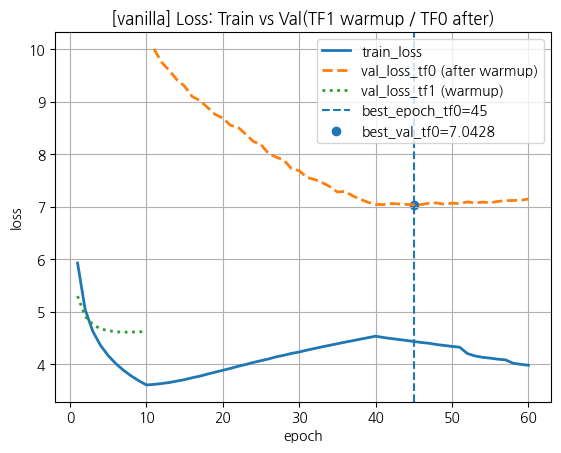

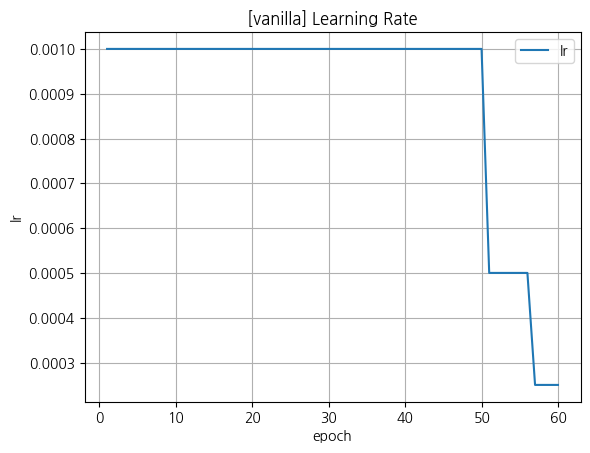

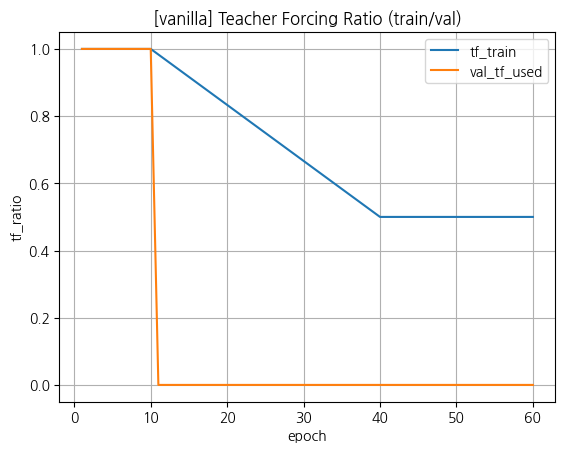

[vanilla] Attention metrics 없음(=vanilla이거나 기록 None).


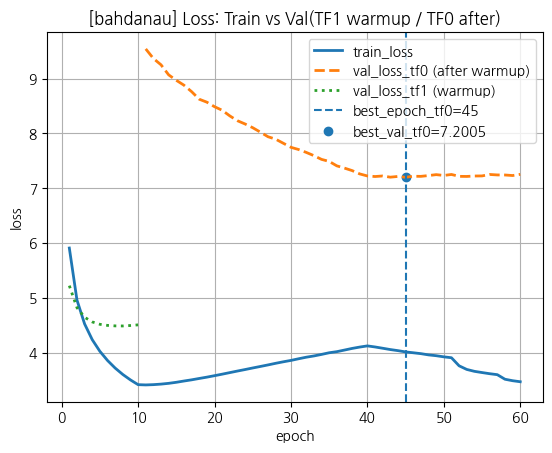

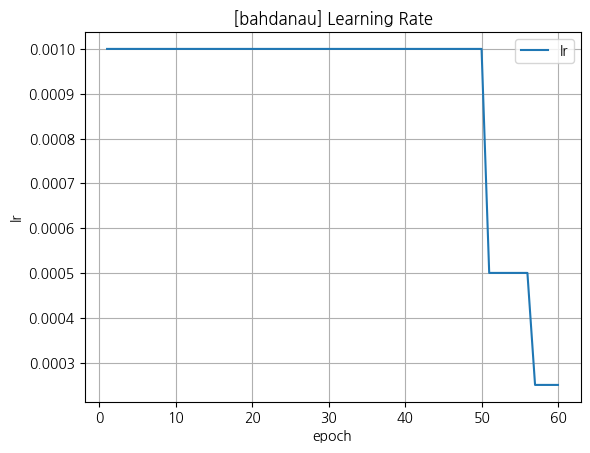

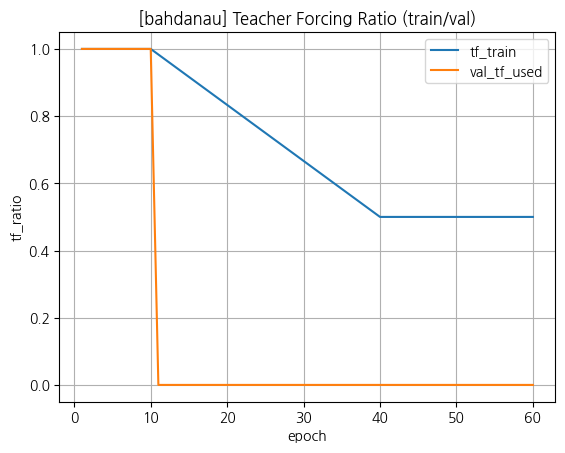

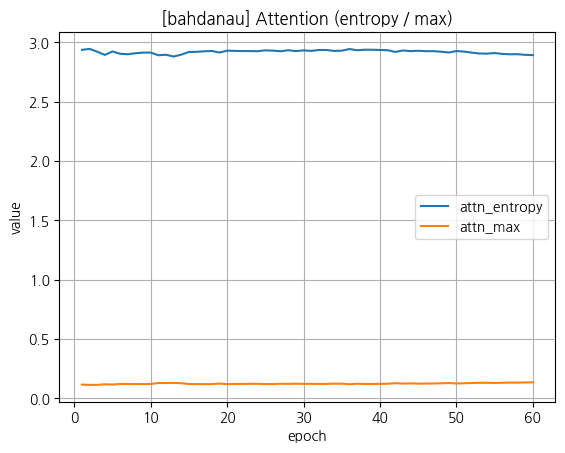

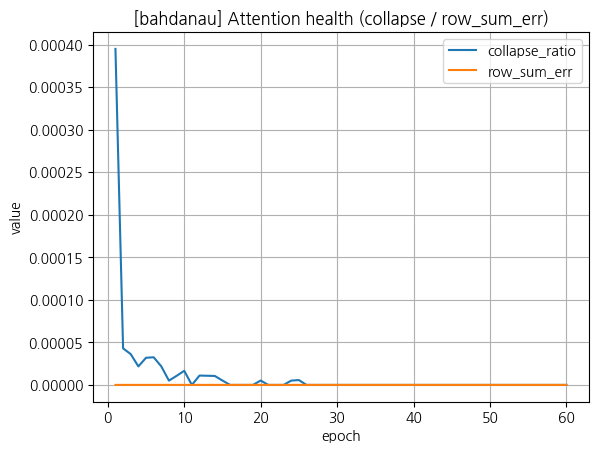

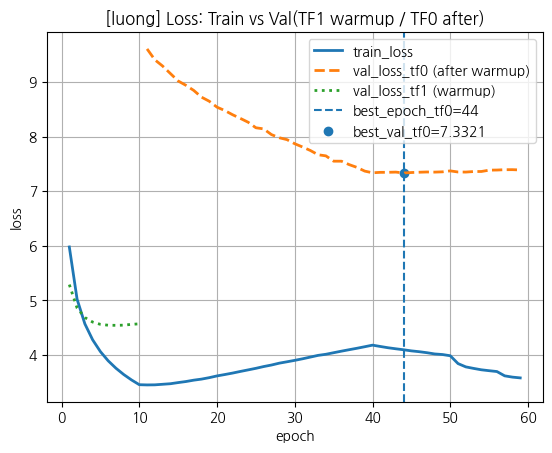

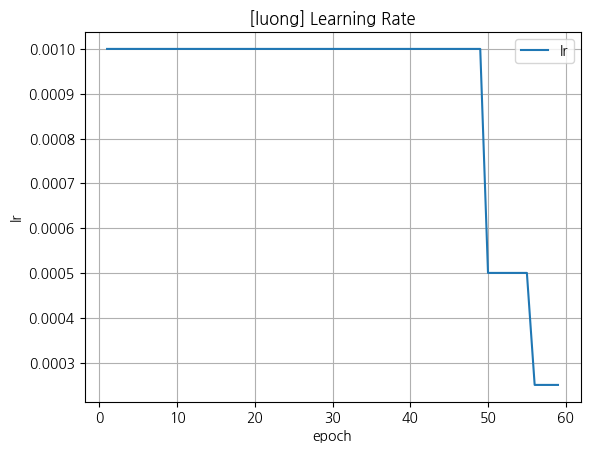

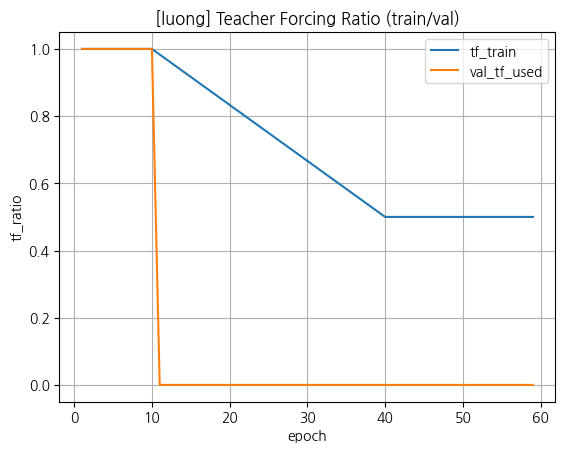

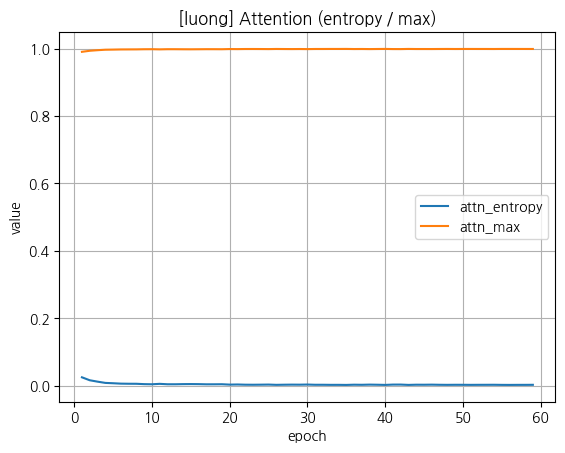

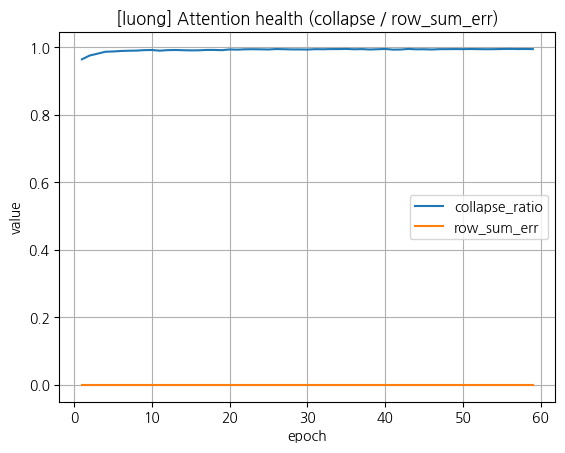

In [75]:
import matplotlib.pyplot as plt
import numpy as np

def _to_float_nan(seq):
    """None -> np.nan 변환"""
    out = []
    for v in seq:
        out.append(np.nan if v is None else float(v))
    return np.array(out, dtype=float)

def plot_loss_for_one(history, name="run"):
    train = _to_float_nan(history.get("train_loss", []))
    val0  = _to_float_nan(history.get("val_loss_tf0", []))  # warmup엔 nan
    val1  = _to_float_nan(history.get("val_loss_tf1", []))  # warmup엔 값, 이후 nan

    epochs = np.arange(1, len(train) + 1)

    plt.figure()
    plt.plot(epochs, train, label="train_loss", linewidth=2)

    # 둘 다 그리되, nan 구간은 자동으로 끊겨서 표시됨
    if len(val0) == len(train):
        plt.plot(epochs, val0, label="val_loss_tf0 (after warmup)", linestyle="--", linewidth=2)
    if len(val1) == len(train):
        plt.plot(epochs, val1, label="val_loss_tf1 (warmup)", linestyle=":", linewidth=2)

    # best tf0 표시
    best_epoch = history.get("best_epoch_tf0", None)
    best_val   = history.get("best_val_loss_tf0", None)
    if isinstance(best_epoch, int) and best_epoch > 0:
        plt.axvline(best_epoch, linestyle="--", label=f"best_epoch_tf0={best_epoch}")
        if best_val is not None and np.isfinite(best_val):
            plt.scatter([best_epoch], [best_val], marker="o", label=f"best_val_tf0={best_val:.4f}")

    plt.title(f"[{name}] Loss: Train vs Val(TF1 warmup / TF0 after)")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.grid(True); plt.legend()
    plt.show()

def plot_aux_for_one(history, name="run"):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)

    lr = _to_float_nan(history.get("lr", []))
    tf_train = _to_float_nan(history.get("tf_train", []))
    val_tf_used = _to_float_nan(history.get("val_tf_used", []))

    # LR
    if len(lr) == len(epochs):
        plt.figure()
        plt.plot(epochs, lr, label="lr")
        plt.title(f"[{name}] Learning Rate")
        plt.xlabel("epoch"); plt.ylabel("lr")
        plt.grid(True); plt.legend()
        plt.show()

    # TF ratios
    if len(tf_train) == len(epochs) or len(val_tf_used) == len(epochs):
        plt.figure()
        if len(tf_train) == len(epochs):
            plt.plot(epochs, tf_train, label="tf_train")
        if len(val_tf_used) == len(epochs):
            plt.plot(epochs, val_tf_used, label="val_tf_used")
        plt.title(f"[{name}] Teacher Forcing Ratio (train/val)")
        plt.xlabel("epoch"); plt.ylabel("tf_ratio")
        plt.grid(True); plt.legend()
        plt.show()

def plot_attention_for_one(history, name="run"):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)

    ent = _to_float_nan(history.get("attn_entropy", []))
    amax = _to_float_nan(history.get("attn_max", []))
    rowerr = _to_float_nan(history.get("row_sum_err", []))
    collapse = _to_float_nan(history.get("collapse_ratio", []))

    # vanilla는 attn_*가 전부 None일 수 있음 → 그 경우 스킵
    if np.all(np.isnan(ent)) and np.all(np.isnan(amax)) and np.all(np.isnan(collapse)):
        print(f"[{name}] Attention metrics 없음(=vanilla이거나 기록 None).")
        return

    # 1) entropy + max 같이 (집중/붕괴 감)
    plt.figure()
    if len(ent) == len(epochs):
        plt.plot(epochs, ent, label="attn_entropy")
    if len(amax) == len(epochs):
        plt.plot(epochs, amax, label="attn_max")
    plt.title(f"[{name}] Attention (entropy / max)")
    plt.xlabel("epoch"); plt.ylabel("value")
    plt.grid(True); plt.legend()
    plt.show()

    # 2) collapse + row_sum_err
    plt.figure()
    if len(collapse) == len(epochs):
        plt.plot(epochs, collapse, label="collapse_ratio")
    if len(rowerr) == len(epochs):
        plt.plot(epochs, rowerr, label="row_sum_err")
    plt.title(f"[{name}] Attention health (collapse / row_sum_err)")
    plt.xlabel("epoch"); plt.ylabel("value")
    plt.grid(True); plt.legend()
    plt.show()

def plot_all_models(model_history, show_attention=True):
    print("models in model_history:", list(model_history.keys()))
    for name, hist in model_history.items():
        plot_loss_for_one(hist, name=name)
        plot_aux_for_one(hist, name=name)
        if show_attention:
            plot_attention_for_one(hist, name=name)

# ✅ 실행: 이 한 줄이면 바닐라/바다나우/루엉 모두 나옵니다.
plot_all_models(model_history, show_attention=True)

In [71]:
print("train_loss len:", len(hist.get("train_loss", [])))
print("val_loss_tf0 len:", len(hist.get("val_loss_tf0", [])))
print("val_loss_tf1 len:", len(hist.get("val_loss_tf1", [])))

train_loss len: 60
val_loss_tf0 len: 60
val_loss_tf1 len: 60


In [85]:
# ============================================================
# [STEP 5-CELL 5] (훈련 종료 후) BEST 로드 → TEST 최종 1회 평가
# ------------------------------------------------------------
# ✅ 출력:
#  - Track-A: Teacher-Forced TEST Loss (TF=1.0) + 붕괴 지표(ent/max/collapse)
#  - Track-B: Greedy free-run subset 번역 + end_rate/avg_len
# ✅ 저장:
#  - step5_test_results 딕셔너리 (Step6 비교 테이블에 그대로 사용)
# ============================================================

# ============================================================
# [STEP 5-CELL 5 - FIXED] BEST 로드 → TEST 최종 1회 평가
# ------------------------------------------------------------
# - TF0 기준 best 정보 안전하게 저장
# - KeyError 완전 방지
# ============================================================

import os
import torch
import torch.nn as nn

assert os.path.isdir(CKPT_DIR), f"체크포인트 폴더가 없습니다: {CKPT_DIR}"

criterion_test = nn.CrossEntropyLoss(
    ignore_index=eng_sp.pad_id(),
    label_smoothing=0.0
)

@torch.no_grad()
def eval_test_tf1(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    ent_sum, max_sum, rowerr_sum, coll_sum, attn_batches = 0.0, 0.0, 0.0, 0.0, 0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        logits, attn_all = model(
            src, src_len, dec_in,
            teacher_forcing_ratio=1.0
        )

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )
        total_loss += float(loss.item())

        m = compute_attn_metrics(attn_all)
        if m["attn_entropy"] is not None:
            ent_sum += m["attn_entropy"]
            max_sum += m["attn_max"]
            rowerr_sum += m["row_sum_err"]
            coll_sum += m["collapse_ratio"]
            attn_batches += 1

    test_loss = total_loss / max(1, len(loader))

    if attn_batches > 0:
        attn_metrics = {
            "attn_entropy": ent_sum / attn_batches,
            "attn_max": max_sum / attn_batches,
            "row_sum_err": rowerr_sum / attn_batches,
            "collapse_ratio": coll_sum / attn_batches,
        }
    else:
        attn_metrics = {
            "attn_entropy": None,
            "attn_max": None,
            "row_sum_err": None,
            "collapse_ratio": None,
        }

    return test_loss, attn_metrics


@torch.no_grad()
def trackB_free_run_subset(model, subset_kor, max_len=60):
    model.eval()
    end_id = int(eng_sp.PieceToId("<end>"))

    lens = []
    ended = 0
    preds = []

    for s in subset_kor:
        src_ids = kor_sp.EncodeAsIds(s)
        dec_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
        lens.append(len(dec_ids))

        if end_id in dec_ids[1:]:
            ended += 1

        preds.append((s, detokenize_eval(eng_sp, dec_ids)))

    end_rate = ended / max(1, len(subset_kor))
    avg_len = sum(lens) / max(1, len(lens))

    return {
        "end_rate": end_rate,
        "avg_len": avg_len,
        "lens": lens,
        "preds": preds
    }


step5_test_results = {}

for name, model in models.items():

    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    assert os.path.isfile(best_path), f"best 체크포인트가 없습니다: {best_path}"

    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n🧪 FINAL TEST (BEST): {name.upper()}")
    print(f" - loaded: {best_path}")

    # -----------------------------
    # Track-A (Teacher Forced)
    # -----------------------------
    test_loss_tf1, attn_m = eval_test_tf1(model, test_loader, criterion_test)

    print(f"[Track-A] TEST Loss(tf=1.0): {test_loss_tf1:.4f}")

    if attn_m["attn_entropy"] is not None:
        print(f"         Attn(ent/max/rowerr/collapse): "
              f"{attn_m['attn_entropy']:.3f} / "
              f"{attn_m['attn_max']:.3f} / "
              f"{attn_m['row_sum_err']:.3e} / "
              f"{attn_m['collapse_ratio']:.3f}")
    else:
        print("         Attn metrics: (vanilla) None")

    # -----------------------------
    # Track-B (Free Run)
    # -----------------------------
    free_m = trackB_free_run_subset(model, SUBSET_KOR, max_len=MAX_DECODE_LEN)

    print(f"[Track-B] Free-run subset: "
          f"end_rate={free_m['end_rate']:.2f}, "
          f"avg_len={free_m['avg_len']:.1f}, "
          f"lens={free_m['lens']}")

    for src_s, pred_s in free_m["preds"]:
        print(f"   - SRC: {src_s}")
        print(f"     PRED: {pred_s}")

    # -----------------------------
    # ✅ TF0 기준 best 정보 안전 추출
    # -----------------------------
    best_epoch_tf0 = None
    best_val_tf0 = None
    best_val_tf1 = None

    if name in model_history:
        h = model_history[name]
        best_epoch_tf0 = h.get("best_epoch_tf0", None)
        best_val_tf0   = h.get("best_val_loss_tf0", None)

    # -----------------------------
    # 결과 저장
    # -----------------------------
    step5_test_results[name] = {
        "test_loss_tf1": test_loss_tf1,
        **attn_m,
        "free_end_rate": free_m["end_rate"],
        "free_avg_len": free_m["avg_len"],

        "best_epoch_tf0": best_epoch_tf0,
        "best_val_loss_tf0": best_val_tf0,
        "best_val_loss_tf1": best_val_tf1,
    }

print("\n✅ Step5 final test done.")
print("→ step5_test_results 생성 완료")


🧪 FINAL TEST (BEST): VANILLA
 - loaded: ./checkpoints_step5\best_vanilla.pt
[Track-A] TEST Loss(tf=1.0): 4.8522
         Attn metrics: (vanilla) None
[Track-B] Free-run subset: end_rate=1.00, avg_len=14.0, lens=[11, 14, 17]
   - SRC: 오바마는 대통령이다.
     PRED: obama electains that obama's argument.
   - SRC: 시민들은 도시에 산다.
     PRED: buildings bulldozersers and houses in the nearby buildings.
   - SRC: 커피는 필요 없다.
     PRED: didn't want to see how much food can be be checked out.

🧪 FINAL TEST (BEST): BAHDANAU
 - loaded: ./checkpoints_step5\best_bahdanau.pt
[Track-A] TEST Loss(tf=1.0): 4.9323
         Attn(ent/max/rowerr/collapse): 2.983 / 0.122 / 2.348e-08 / 0.000
[Track-B] Free-run subset: end_rate=1.00, avg_len=9.3, lens=[7, 8, 13]
   - SRC: 오바마는 대통령이다.
     PRED: obama is a..
   - SRC: 시민들은 도시에 산다.
     PRED: the people are in the.
   - SRC: 커피는 필요 없다.
     PRED: (cnn) coffee coffee coffee is a coffee coffee.

🧪 FINAL TEST (BEST): LUONG
 - loaded: ./checkpoints_step5\best_luong.pt
[Track

## Step 6. 모델 통합 평가 및 어텐션 시각화 최적화
- 목표: 수치적 지표(BLEU, chrF)와 정성적 분석(유형별 Subset)을 결합하여, 모델의 실제 번역 능력과 어텐션 메커니즘의 유효성을 최종 판정함.
### 1. 공정 평가를 위한 전처리 (Detokenization)
- 평가 직전 복원: 토큰화된 상태(예: i 'm .)로 BLEU를 측정하면 구두점 공백 이슈로 점수가 왜곡됨
-  반드시 Step 3에서 확정한 detokenize_eval 규칙을 적용해 "사람이 읽는 문장"으로 복원 후 평가
- 지표 산출: * Corpus BLEU: 전체 테스트셋에 대한 전반적인 번역 정확도 측정.
- chrF: 문자 n-gram 기반 지표로, 형태소가 복잡한 한국어-영어 번역에서 BLEU의 단점을 보완하는 보조 지표로 활용.

### 2. 모델별 성능 비교 리포트
- 지표 대조 테이블: Vanilla vs Bahdanau vs Luong 모델의 BLEU, chrF, 그리고 두 지표의 평균값을 한눈에 비교
- 학습 효율 분석: 각 모델이 최적점에 도달하기까지 걸린 Epoch와 Loss 수렴 속도를 함께 기록

### 3. 유형별 심층 에러 분석 (Subset Analysis)
- 단순 평균 점수 뒤에 숨겨진 모델의 약점을 파악하기 위해 데이터를 3가지 유형으로 분류하여 평가

### 4. Luong Attention 붕괴 검증 및 최종 판정
- 수치 vs 정성 대조: Luong 모델이 BLEU 점수는 높지만,
- 특정 문장에서 어텐션이 마침표(.)에 쏠리거나 엉뚱한 단어를 반복하는지(Hallucination) Subset 번역 예시를 통해 검증
- 최종 모델 선정: 점수, 정렬의 안정성, 문법적 유창성을 종합하여 프로젝트의 최종 번역 모델을 결정

In [79]:
# ============================================================
# [STEP 6-CELL 1] 공정 평가용: TEST 전체 디코딩 + Detokenize_eval 적용
# ------------------------------------------------------------
# ✅ 원칙:
#  - BLEU/chrF는 반드시 사람이 읽는 문장 형태로 복원(detokenize_eval) 후 계산
#  - test_loader는 최종 평가에서만 사용
#  - 여기서는 "각 모델에 대해 test 전체 greedy decode" 결과를 캐시
#
# ⚠️ 비용 큼:
#  - test 전체를 greedy로 뽑는 건 시간이 듭니다(하지만 Step6 목표상 필수)
# ============================================================

import math
import torch

assert "step5_test_results" in globals(), "Step5 test 결과(step5_test_results)가 없습니다. Step5-CELL5를 먼저 실행하세요."

@torch.no_grad()
def greedy_decode_batchwise(model, loader, max_len=60, limit_batches=None):
    """
    test_loader를 돌면서:
      - references(정답 영문) / hypotheses(예측 영문) 리스트 생성
    """
    model.eval()
    refs = []
    hyps = []

    bcount = 0
    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)

        # 정답(참조) 문장: dec_in/dec_out로부터 tgt를 복원한 뒤 detokenize
        # tgt = [<start> ... <end>] (pad 제외)
        # 여기서는 배치마다 sample 단위로 복원
        # dec_in: tgt[:-1], dec_out: tgt[1:]
        # -> tgt 복원은 [dec_in[0]] + last token from dec_out
        # 간단히: tgt_tokens = [<start>] + dec_out_tokens(전체)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        B = src.size(0)
        for i in range(B):
            # ref ids: [dec_in[i,0]] + dec_out[i,:] 에서 pad 제거
            # dec_in은 시작 토큰 포함, dec_out은 끝 토큰 포함
            ref_ids = torch.cat([dec_in[i:i+1, :1], dec_out[i:i+1, :]], dim=1).squeeze(0)  # (T_full,)
            ref_ids = ref_ids[ref_ids != eng_sp.pad_id()].tolist()
            refs.append(detokenize_eval(eng_sp, ref_ids))

            # hyp ids: greedy
            src_ids = src[i][src[i] != kor_sp.pad_id()].tolist()
            hyp_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
            hyps.append(detokenize_eval(eng_sp, hyp_ids))

        bcount += 1
        if (limit_batches is not None) and (bcount >= limit_batches):
            break

    return refs, hyps

# 캐시 저장소
step6_decode_cache = {}   # {model_name: {"refs": [...], "hyps": [...]}}

for name, model in models.items():
    # BEST 로드(안전하게 다시)
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n[STEP6] Decoding TEST for: {name}")
    refs, hyps = greedy_decode_batchwise(model, test_loader, max_len=MAX_DECODE_LEN, limit_batches=None)
    step6_decode_cache[name] = {"refs": refs, "hyps": hyps}
    print(f" - decoded pairs: {len(refs)}")

print("\n✅ Step6 decode cache ready: step6_decode_cache")


[STEP6] Decoding TEST for: vanilla
 - decoded pairs: 1798

[STEP6] Decoding TEST for: bahdanau
 - decoded pairs: 1798

[STEP6] Decoding TEST for: luong
 - decoded pairs: 1798

✅ Step6 decode cache ready: step6_decode_cache


In [87]:
# ============================================================
# [STEP 6-CELL 2] Corpus BLEU + chrF 계산 + 비교 테이블 생성
# ------------------------------------------------------------
# ✅ 지표:
#  - BLEU: corpus-level (기본 4-gram)
#  - chrF: 문자 n-gram 기반 (한국어/영어 혼합에서 BLEU 보완)
# ✅ 출력:
#  - 모델별 BLEU/chrF/평균 + (Step5의 best_epoch, loss 수렴 정보 결합)
# ============================================================

import math
import pandas as pd

# --- sacrebleu import ---
def _try_import_sacrebleu():
    try:
        import sacrebleu
        return sacrebleu
    except Exception:
        return None

sacrebleu = _try_import_sacrebleu()

def compute_metrics_bleu_chrf(refs, hyps):
    assert len(refs) == len(hyps), "refs/hyps 길이 불일치"
    if sacrebleu is None:
        return {"bleu": float("nan"), "chrf": float("nan"), "note": "sacrebleu not installed"}
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf = sacrebleu.corpus_chrf(hyps, [refs]).score
    return {"bleu": float(bleu), "chrf": float(chrf), "note": "ok"}

# --- Key normalization map: step5_test_results 키를 소문자로 매핑 ---
assert isinstance(step5_test_results, dict), "step5_test_results가 dict가 아닙니다."
step5_keymap = {k.lower(): k for k in step5_test_results.keys()}

def get_step5_pack(model_name: str):
    """model_name(예: bahdanau)로 step5_test_results에서 해당 pack을 안전하게 가져옴"""
    k = step5_keymap.get(model_name.lower(), None)
    return step5_test_results.get(k, {}) if k is not None else {}

rows = []
for name, pack in step6_decode_cache.items():
    refs, hyps = pack["refs"], pack["hyps"]
    m = compute_metrics_bleu_chrf(refs, hyps)

    s5 = get_step5_pack(name)  # ✅ 안전 조회 (대소문자/표기 차이 대응)

    rows.append({
        "model": name,
        "BLEU": m["bleu"],
        "chrF": m["chrf"],
        "BLEU_chrF_avg": (m["bleu"] + m["chrf"]) / 2.0
            if (not math.isnan(m["bleu"]) and not math.isnan(m["chrf"]))
            else float("nan"),

        # ✅ Step5 결과(없으면 None)
        "best_epoch_tf0": s5.get("best_epoch_tf0"),
        "best_val_loss_tf0": s5.get("best_val_loss_tf0"),
        "test_loss_tf1": s5.get("test_loss_tf1"),

        "collapse_ratio": s5.get("collapse_ratio"),
        "attn_max": s5.get("attn_max"),
        "attn_entropy": s5.get("attn_entropy"),

        "note": m["note"],
    })

report_df = pd.DataFrame(rows).sort_values(by=["BLEU_chrF_avg","BLEU","chrF"], ascending=False)
print(report_df)
print("\n✅ Step6 report_df ready (model comparison table).")

      model      BLEU       chrF  BLEU_chrF_avg  best_epoch_tf0  \
1  bahdanau  3.536002  22.066376      12.801189              45   
2     luong  2.982298  19.445395      11.213846              44   
0   vanilla  2.664638  19.557280      11.110959              45   

   best_val_loss_tf0  test_loss_tf1  collapse_ratio  attn_max  attn_entropy  \
1           7.200488       4.932315        0.000000  0.122215      2.983212   
2           7.332131       5.066085        0.995278  0.998787      0.002911   
0           7.042828       4.852245             NaN       NaN           NaN   

  note  
1   ok  
2   ok  
0   ok  

✅ Step6 report_df ready (model comparison table).


In [89]:
# ============================================================
# [STEP 6-CELL 3] 유형별 Subset Analysis (정성 + 간단 정량)
# ------------------------------------------------------------
# ✅ 목적:
#  - 평균 점수(BLEU/chrF) 뒤에 숨은 약점 노출
# ✅ 유형 예시:
#  1) SHORT: 짧은 문장
#  2) NEG: 부정문
#  3) NNP: 고유명사/인명/지명 포함
#
# ✅ 출력:
#  - 모델별 유형 subset 번역 예시(Detokenize_eval로 출력)
#  - (원하면 여기서 유형별 BLEU/chrF도 별도 산출 가능)
# ============================================================

TYPE_SUBSETS = {
    "SHORT": [
        "나는 간다.",
        "그는 왔다.",
        "비가 온다.",
    ],
    "NEG": [
        "커피는 필요 없다.",
        "나는 그것을 원하지 않는다.",
        "그는 오지 못했다.",
    ],
    "NNP": [
        "오바마는 대통령이다.",
        "서울은 한국의 수도이다.",
        "테슬라는 전기차 회사다.",
    ],
}

@torch.no_grad()
def show_subset_outputs(model, subset_dict, max_len=60):
    out = {}
    for typ, sents in subset_dict.items():
        out[typ] = []
        for s in sents:
            pred, _ = sample_translate(model, s, max_len=max_len)
            out[typ].append((s, pred))
    return out

step6_subset_outputs = {}

for name, model in models.items():
    # BEST 로드
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n[Subset Analysis] {name.upper()}")
    out = show_subset_outputs(model, TYPE_SUBSETS, max_len=MAX_DECODE_LEN)
    step6_subset_outputs[name] = out

    for typ, pairs in out.items():
        print(f" - TYPE: {typ}")
        for src_s, pred_s in pairs:
            print(f"   SRC : {src_s}")
            print(f"   PRED: {pred_s}")

print("\n✅ Step6 subset outputs cached: step6_subset_outputs")


[Subset Analysis] VANILLA
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: i saw a huge shootout, i'm sure i'm.
   SRC : 그는 왔다.
   PRED: he was a a to the the.
   SRC : 비가 온다.
   PRED: temperatures in the and the the the
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: didn't want to see how much food can be be checked out.
   SRC : 나는 그것을 원하지 않는다.
   PRED: i don't want to know what i want to do with the.
   SRC : 그는 오지 못했다.
   PRED: he was not to the.
 - TYPE: NNP
   SRC : 오바마는 대통령이다.
   PRED: obama electains that obama's argument.
   SRC : 서울은 한국의 수도이다.
   PRED: seoul seoul seoul is seoul, seoul, seoul, seoul, seoul, seoul, seoul, seoul.
   SRC : 테슬라는 전기차 회사다.
   PRED: instead of the,, noodles,

[Subset Analysis] BAHDANAU
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: the is bizarre.
   SRC : 그는 왔다.
   PRED: he was.
   SRC : 비가 온다.
   PRED: visibility.
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: (cnn) coffee coffee coffee is a coffee coffee.
   SRC : 나는 그것을 원하지 않는다.
   PRED: don't want.
   SRC : 그는 오지 못했다.


In [91]:
# ============================================================
# [STEP 6-CELL 4] Luong Attention 붕괴 검증 & 최종 판정 보조로그
# ------------------------------------------------------------
# ✅ 목적:
#  - "점수는 높은데 실제 번역이 이상" / "어텐션이 특정 토큰에 쏠림" 판별
# ✅ 출력:
#  - luong 모델의 collapse_ratio/attn_max/entropy + subset 번역 예시를 같이 제시
#
# 🔥 최종 모델 선정 기준(권장):
#  1) BLEU/chrF 평균
#  2) test_loss_tf1 + 수렴 속도(best_epoch)
#  3) collapse_ratio 낮음(붕괴 적음), attn_entropy 합리적(너무 낮으면 쏠림 의심)
#  4) Subset 번역에서 반복/환각/마침표 집착 여부
# ============================================================

def summarize_model(name):
    r = step5_test_results.get(name, {})
    row = {
        "model": name,
        "test_loss_tf1": r.get("test_loss_tf1"),
        "best_epoch": r.get("best_epoch"),
        "best_val_loss_tf1": r.get("best_val_loss_tf1"),
        "attn_entropy": r.get("attn_entropy"),
        "attn_max": r.get("attn_max"),
        "collapse_ratio": r.get("collapse_ratio"),
    }
    return row

# Luong 집중 출력
target = "luong"
print("[LUONG SUMMARY]")
print(summarize_model(target))

print("\n[LUONG Subset Outputs]")
for typ, pairs in step6_subset_outputs[target].items():
    print(f" - TYPE: {typ}")
    for src_s, pred_s in pairs:
        print(f"   SRC : {src_s}")
        print(f"   PRED: {pred_s}")

print("\n✅ Step6 Luong collapse check complete.")

[LUONG SUMMARY]
{'model': 'luong', 'test_loss_tf1': 5.066084976853995, 'best_epoch': None, 'best_val_loss_tf1': None, 'attn_entropy': 0.0029108937274149238, 'attn_max': 0.9987869057162054, 'collapse_ratio': 0.9952779186183008}

[LUONG Subset Outputs]
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: i'm.
   SRC : 그는 왔다.
   PRED: he has a
   SRC : 비가 온다.
   PRED: the.
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: the caffeine is no.
   SRC : 나는 그것을 원하지 않는다.
   PRED: i don't want.
   SRC : 그는 오지 못했다.
   PRED: he was not.
 - TYPE: NNP
   SRC : 오바마는 대통령이다.
   PRED: obama.
   SRC : 서울은 한국의 수도이다.
   PRED: the seoul central seoul.
   SRC : 테슬라는 전기차 회사다.
   PRED: the company is a promotion.

✅ Step6 Luong collapse check complete.


[OK] loaded best_bahdanau: ./checkpoints_step5\best_bahdanau.pt
[OK] loaded best_luong: ./checkpoints_step5\best_luong.pt


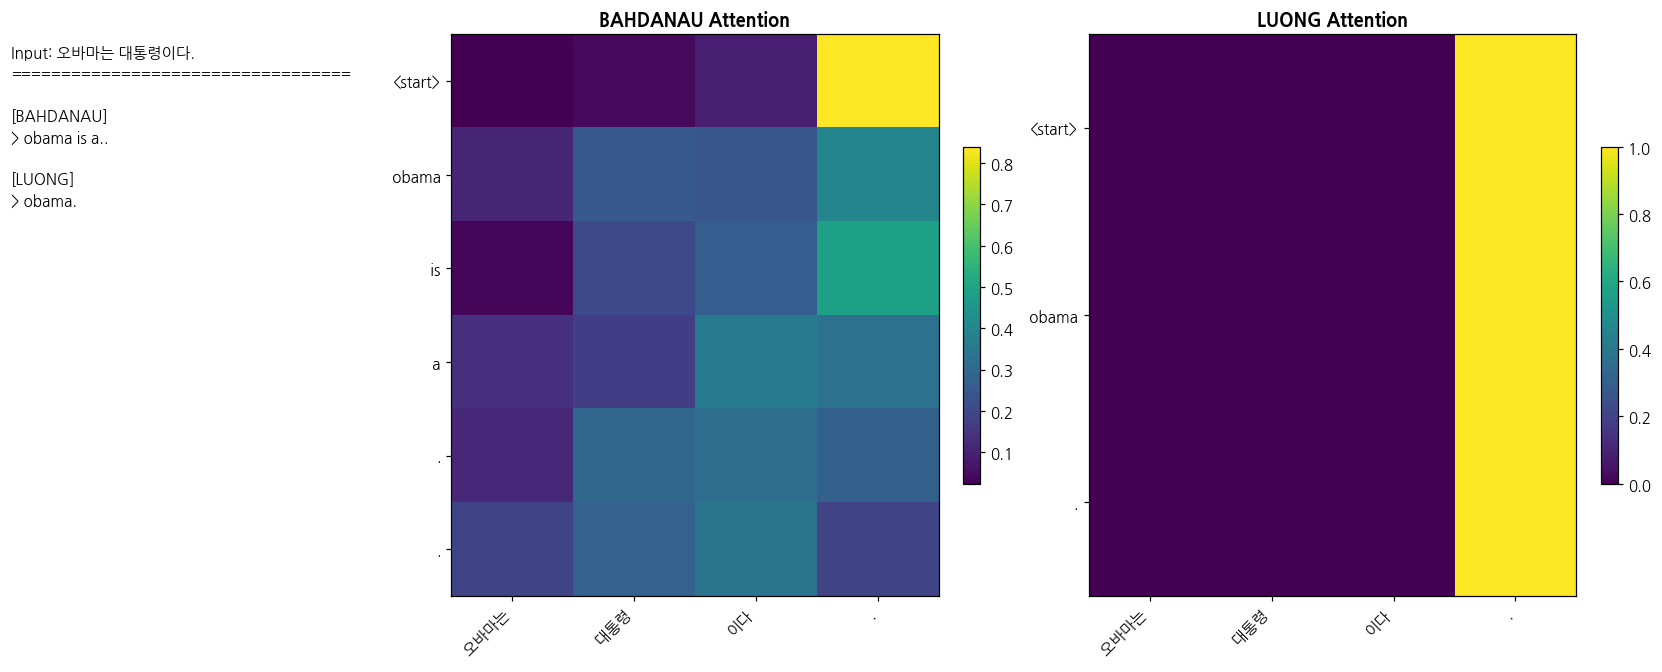

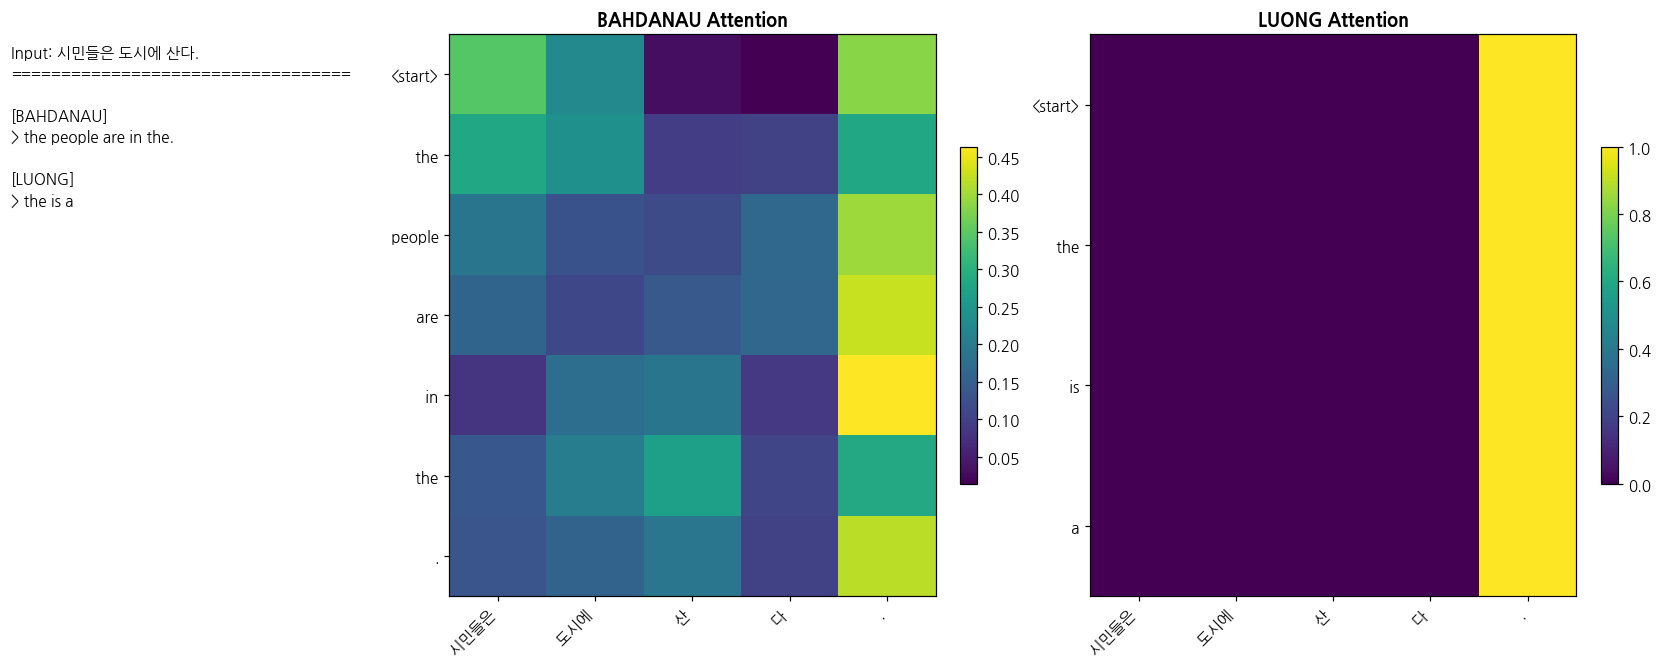

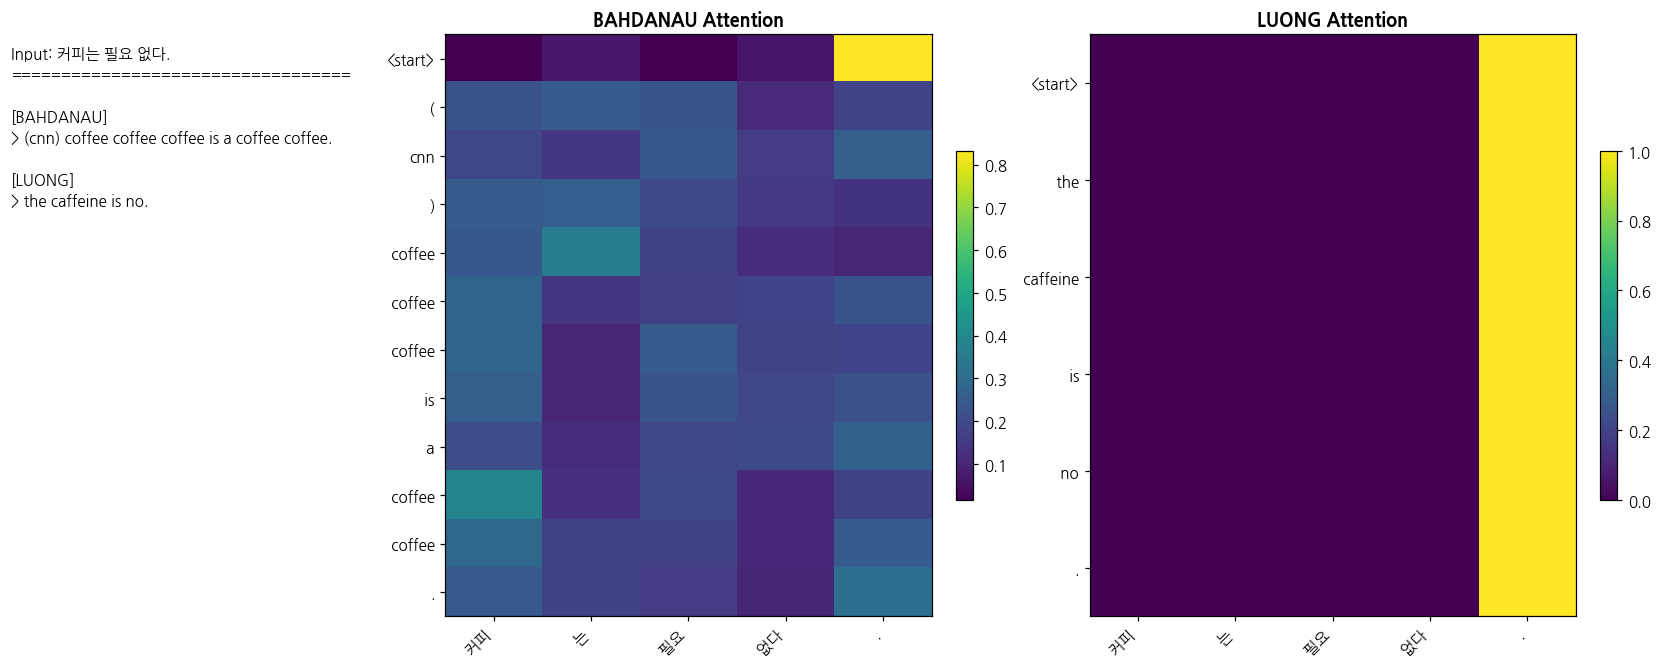

In [107]:
# ============================================================
# [STEP 6-CELL 2 - FINAL FIX] 어텐션 맵 시각화 (Bahdanau vs Luong)
# - 좌측: 입력/번역 텍스트
# - 우측: Bahdanau / Luong attention heatmap 나란히
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# -----------------------------
# 0) 폰트 설정
# -----------------------------
def get_font_prop():
    paths = [
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for p in paths:
        if os.path.exists(p):
            return fm.FontProperties(fname=p)
    return None

font_prop = get_font_prop()

def pretty_piece(p: str) -> str:
    return p.replace("▁", " ")

# -----------------------------
# 1) best 체크포인트 로드
# -----------------------------
def load_best_ckpt_to_model(model, name):
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    assert os.path.isfile(best_path), f"best 체크포인트 없음: {best_path}"

    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return best_path

# -----------------------------
# 2) attn_map → 2D numpy 변환
# -----------------------------
def to_attn_2d(attn_map):

    if attn_map is None:
        return None

    # ✅ numpy array (선생님 케이스)
    if isinstance(attn_map, np.ndarray):
        if attn_map.ndim == 2:
            return attn_map
        if attn_map.ndim == 3:
            return attn_map[0]
        return None

    # list / tuple
    if isinstance(attn_map, (list, tuple)):
        mats = []
        for a in attn_map:
            if torch.is_tensor(a):
                a = a.detach().cpu().squeeze()
            else:
                a = torch.tensor(a).detach().cpu().squeeze()
            mats.append(a)
        if len(mats) == 0:
            return None
        M = torch.stack(mats, dim=0)
        return M.numpy()

    # torch tensor
    if torch.is_tensor(attn_map):
        A = attn_map.detach().cpu()
        if A.dim() == 2:
            return A.numpy()
        if A.dim() == 3:
            return A[0].numpy()

    return None

# -----------------------------
# 3) 핵심 비교 시각화
# -----------------------------
def plot_attention_comparison(models_dict, kor_sentence, max_src=25, max_tgt=20):

    fig = plt.figure(figsize=(15, 6), dpi=110, constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[0.9, 1.2, 1.2])

    src_pieces = [pretty_piece(p) for p in kor_sp.EncodeAsPieces(kor_sentence)]
    S = min(len(src_pieces), max_src)
    src_pieces = src_pieces[:S]
    src_ids = kor_sp.EncodeAsIds(kor_sentence)

    info_lines = []
    info_lines.append(f"Input: {kor_sentence}")
    info_lines.append("=" * 34)

    target_models = ["bahdanau", "luong"]

    for idx, name in enumerate(target_models):

        if name not in models_dict:
            continue

        pred_ids, attn_map = greedy_decode(models_dict[name], src_ids, max_len=MAX_DECODE_LEN)

        pred_text = detokenize_eval(eng_sp, pred_ids)
        tgt_pieces = [pretty_piece(eng_sp.IdToPiece(int(t))) for t in pred_ids]

        info_lines.append(f"\n[{name.upper()}]")
        info_lines.append(f"> {pred_text}")

        A = to_attn_2d(attn_map)

        if A is None:
            info_lines.append("(attention map missing)")
            continue

        T = min(len(tgt_pieces), max_tgt, A.shape[0])
        S2 = min(S, A.shape[1])

        A = A[:T, :S2]
        tgt_pieces = tgt_pieces[:T]
        src_show = src_pieces[:S2]

        ax = fig.add_subplot(gs[0, idx + 1])

        # ✅ 자동 스케일 → 무조건 보임
        im = ax.imshow(A, aspect="auto")

        ax.set_title(f"{name.upper()} Attention", fontsize=12, fontweight="bold")

        ax.set_xticks(range(S2))
        ax.set_xticklabels(src_show, rotation=45, ha="right",
                           fontsize=9, fontproperties=font_prop)

        ax.set_yticks(range(T))
        ax.set_yticklabels(tgt_pieces, fontsize=9, fontproperties=font_prop)

        fig.colorbar(im, ax=ax, shrink=0.6)

    ax_info = fig.add_subplot(gs[0, 0])
    ax_info.axis("off")
    ax_info.text(0, 0.98, "\n".join(info_lines), va="top",
                 fontsize=10, linespacing=1.5, fontproperties=font_prop)

    plt.show()

# -----------------------------
# 4) 실행
# -----------------------------
assert "bahdanau" in models and "luong" in models

loaded_models = {
    "bahdanau": models["bahdanau"],
    "luong": models["luong"]
}

for n in ["bahdanau", "luong"]:
    p = load_best_ckpt_to_model(loaded_models[n], n)
    print(f"[OK] loaded best_{n}: {p}")

for s in ["오바마는 대통령이다.", "시민들은 도시에 산다.", "커피는 필요 없다."]:
    plot_attention_comparison(loaded_models, s, max_src=25, max_tgt=20)